In [2]:
%matplotlib widget

Per ogni sorgente modificare:
- z e controllare che lambda lines corrisponda
- sigma e seeing
- n_component
- regione estrazione cielo
- taglio immagine in y
- funzioni di plot e model_convolved
- bounds_HA (ampiezza dell'intervallo sulle x è +- la metà del seeing) e bounds
- salvataggio fit

In [3]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from astropy.modeling import models
from scipy.signal import convolve
from scipy.optimize import minimize
from astropy.convolution import Gaussian1DKernel
import scipy.integrate as integrate
from scipy.optimize import differential_evolution
import pandas as pd
import os

In [4]:
hdul = fits.open("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/MGC+01-02-017/MGC+01-02-017_1/FORS2.2021-10-04T04_41_52.988/MCG+01-02-017_1_MAPPED_FLUX_SCI_LSS_U1.fits")
hdul.info()
image = hdul[0].data
image_error = hdul[1].data

Filename: C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/MGC+01-02-017/MGC+01-02-017_1/FORS2.2021-10-04T04_41_52.988/MCG+01-02-017_1_MAPPED_FLUX_SCI_LSS_U1.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     361   (2094, 963)   float32   
  1  IMAGE.ERR     1 ImageHDU        42   (2094, 963)   float32   


In [5]:
image_cut = image[61:161, 0:1890]
image_error_cut = image_error[61:161, 0:1890]

Text(0.5, 0, 'wavelength')

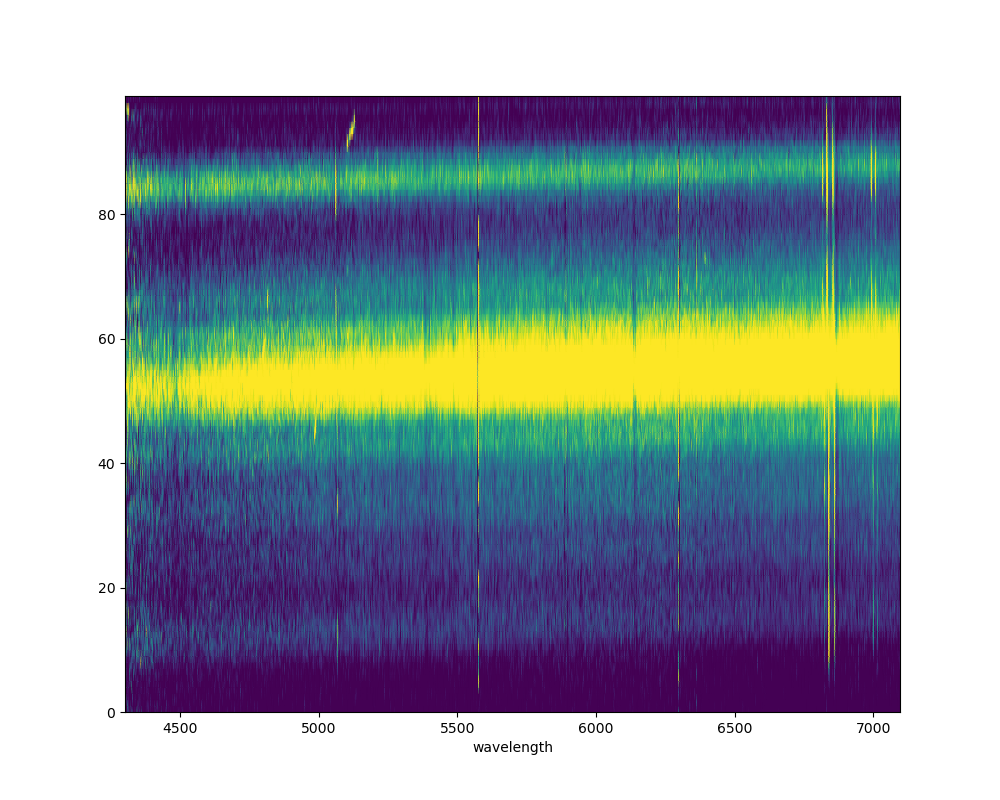

In [6]:
wv = np.arange(4300.74, 4300.74+1890*1.48, 1.48)
J, N = image_cut.data.shape
#x = np.arange(0, N, 1)
y = np.arange(0, J, 1)
arcsec_y = np.arange(-58*0.256, 42*0.256, 0.256)

x_grid, y_grid = np.meshgrid(wv, y)
plt.figure(figsize=(10,8))
plt.pcolormesh(x_grid, y_grid, image_cut, shading='gouraud', vmin=np.percentile(image_cut, 15), vmax=np.percentile(image_cut, 90))
plt.xlabel('wavelength')

## Redshift or the lines in air

In [7]:
z = 0.0429
l_HA = 6563 * (1+z)
l_HB = 4861 * (1+z) 
l_NII = 6583 * (1+z)
l_SII = 6717 * (1+z)
l_OIII = 5007 * (1+z)

seeing = np.loadtxt("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/MGC+01-02-017/PSF/Real_seeing_MCG+01-02-017.txt")
sigmas = seeing / 2.35
print(sigmas)

[1.33471019 1.53160171 1.33432652 1.33446935 1.50981433 1.35106383]


## Sky lines

Filename: C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/MGC+01-02-017/MGC+01-02-017_1/FORS2.2021-10-04T04_41_52.988/MCG+01-02-017_1_MAPPED_FLUX_SCI_LSS_U1.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     361   (2094, 963)   float32   
  1  IMAGE.ERR     1 ImageHDU        42   (2094, 963)   float32   


Text(0.5, 0, 'wavelength')

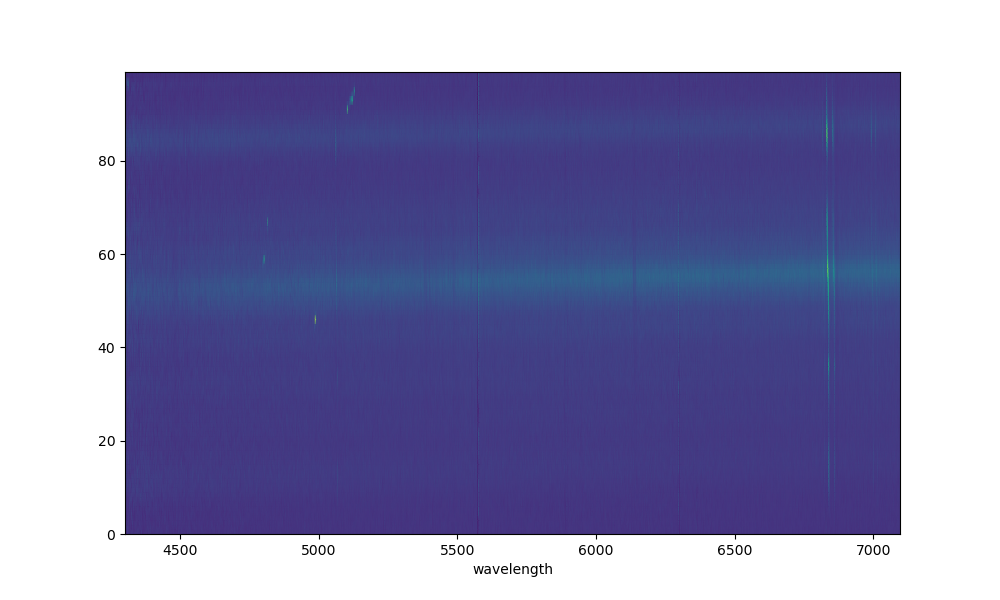

In [8]:
hdul2 = fits.open("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/MGC+01-02-017/MGC+01-02-017_1/FORS2.2021-10-04T04_41_52.988/MCG+01-02-017_1_MAPPED_FLUX_SCI_LSS_U1.fits")
hdul2.info()
image2 = hdul2[0].data
image_cut2 = image2[61:161, 0:1890]

x_grid, y_grid = np.meshgrid(wv, y)
plt.figure(figsize=(10, 6))
plt.pcolormesh(x_grid, y_grid, image_cut2, shading='gouraud')#, vmin = np.percentile(image_cut, 20), vmax = 0.16)
plt.xlabel('wavelength')

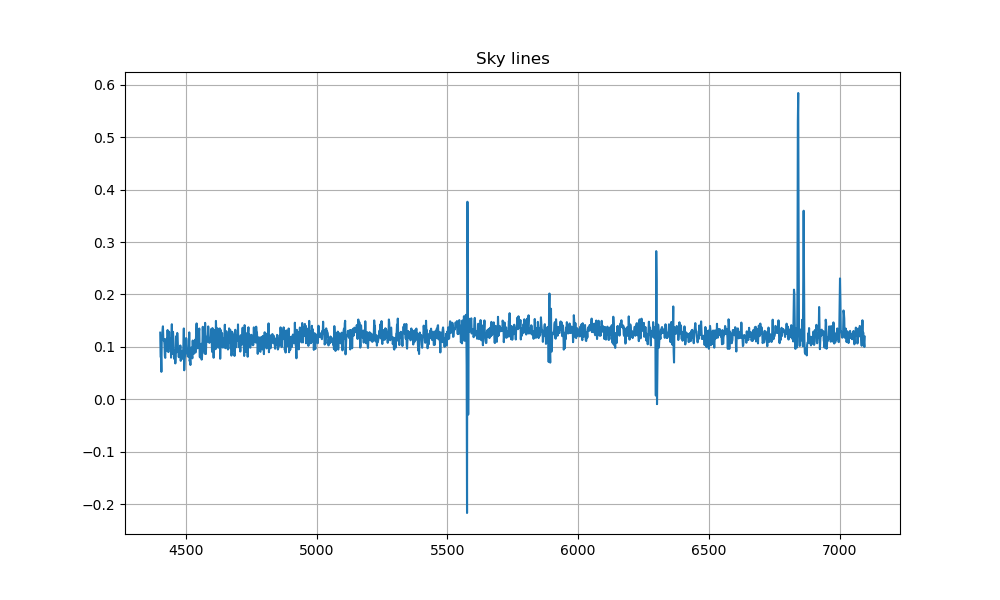

In [9]:
mask_sky = (y > 15)*(y < 25)
mask_wv = wv > 4400
image_sky = image_cut2[np.ix_(mask_sky, mask_wv)]
radial_profile_sky = np.sum(image_sky, axis = 0)
plt.figure(figsize=(10, 6))
plt.plot(wv[mask_wv], radial_profile_sky)
#x_interval = np.arange(4300, 4300+1800*1.48, 250)
#plt.xticks(x_interval)
plt.grid()
plt.title(r'Sky lines')

plt.savefig('Sky_lines')

## H$\alpha$

Text(0.5, 1.0, 'H$\\alpha$')

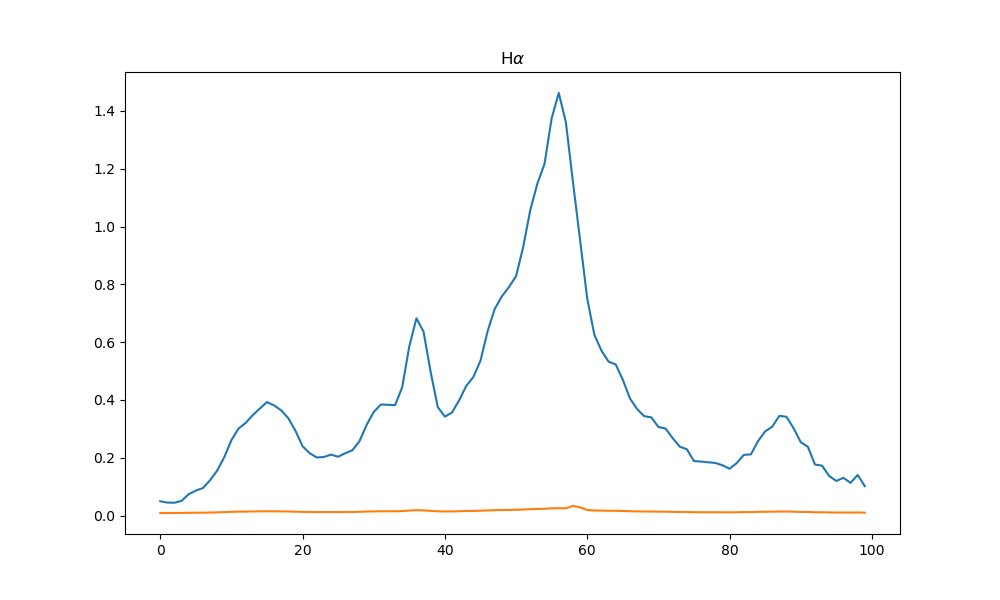

In [10]:
mask_HA = (wv > l_HA-8)*(wv < l_HA+8)
image_HA = image_cut[:, mask_HA]
image_error_HA = image_error_cut[:, mask_HA]
radial_profile_HA = np.sum(image_HA, axis = 1)
radial_profile_error_HA = np.sqrt(np.sum(image_error_HA**2, axis = 1))

sky_err = np.loadtxt("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/MGC+01-02-017/MGC+01-02-017_1/FORS2.2021-10-04T04_41_52.988/Propag_errori/Sky_errors.txt")
real_errors_HA = np.sqrt(radial_profile_error_HA**2+(sky_err[2])**2+(0.04*radial_profile_HA)**2)

x_axes = np.arange(0, 100, 1)
plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_HA)
plt.plot(x_axes, radial_profile_error_HA)
plt.title(r'H$\alpha$')

In [11]:
n_component = 5

def calculate_bn(n):
    """ Calcola b_n per il profilo Sérsic """
    return 2*n - 1/3 + 4/(405*n) + 46/(25515*n**2)

def sersic_1d(x, I_e, r_e, n, x_0):
    """ Profilo Sérsic 1D centrato in x_0 """
    r = np.abs(x - x_0)
    b_n = calculate_bn(n)
    return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))

def model_convolved(x, sigma, *params):
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = (
        sersic_1d(x_hr, *params[0:4]) +
        sersic_1d(x_hr, *params[4:8]) +
        sersic_1d(x_hr, *params[8:12]) +
        sersic_1d(x_hr, *params[12:16]) +
        sersic_1d(x_hr, *params[16:20])# +
        #sersic_1d(x_hr, *params[20:24])
    )
    kernel = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')   
    conv_profile = convolve(profile, kernel, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def chi_squared(params, x, y_obs, sigma):
    y_model = model_convolved(x, sigma, *params)
    return np.sum((y_obs - y_model)**2)

def sersic_1d_convolved(x, I_e, r_e, n, x_0, sigma):
    """ Sérsic convoluto con PSF gaussiana """
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = sersic_1d(x_hr, I_e, r_e, n, x_0)
    psf = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')
    conv_profile = convolve(profile, psf, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def plot_curve(x_axes, params_curve, radial_profile, radial_profile_err, sigma, title = ""):
    y_fit = model_convolved(x_axes, sigma, *params_curve)
    fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

    ax[0].errorbar(x_axes, radial_profile, radial_profile_err, label='Data')
    ax[0].plot(x_axes, y_fit, 'r-', label='Fit')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[0:4], sigma), 'b--', label='Sérsic 1')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[4:8], sigma), 'g--', label='Sérsic 2')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[8:12], sigma), 'm--', label='Sérsic 3')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[12:16], sigma), color='orange', linestyle='--', label='Sérsic 4')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[16:20], sigma), color = 'chocolate', linestyle='--', label='Sérsic 5')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[20:24], sigma), color = 'dodgerblue', linestyle='--', label='Sérsic 6')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[24:28], sigma), color = 'deeppink', linestyle='--', label='Sérsic 7')

    ax[0].set_xlabel("Pixel")
    ax[0].set_ylabel(r'Flux [$10^{-16} erg/(cm^2 s \AA )$]')
    ax[0].set_title(title)
    ax[0].legend()
    ax[0].grid(True)
    ax[0].set_ylim(0, 1.5)
    #ax[0].tight_layout()
    
    ax[1].scatter(x_axes, (radial_profile - y_fit)/radial_profile_err, marker = '+')
    ax[1].axhline(0, color ='red', linestyle ='dashed')
    ax[1].set_ylabel(r'$\chi$')

def plot_diff(x_axes, best_params, radial_profile, sigma, title = ""):
    y_fit = model_convolved(x_axes, sigma, *best_params)

    fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

    ax[0].plot(x_axes, radial_profile, label='Data')
    ax[0].plot(x_axes, y_fit, 'r-', label='Fit')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[0:4], sigma), 'b--', label='Sérsic 1')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[4:8], sigma), 'g--', label='Sérsic 2')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[8:12], sigma), 'm--', label='Sérsic 3')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[12:16], sigma), color='orange', linestyle='--', label='Sérsic 4')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[16:20], sigma), color = 'chocolate', linestyle='--', label='Sérsic 5')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[20:24], sigma), color = 'dodgerblue', linestyle='--', label='Sérsic 6')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[24:28], sigma), color = 'deeppink', linestyle='--', label='Sérsic 7')

    ax[0].set_xlabel("Pixel")
    ax[0].set_ylabel(r'Flux [$10^{-16} erg/(cm^2 s \AA )$]')
    ax[0].set_title(title)
    ax[0].legend()
    ax[0].grid(True)
    ax[0].set_ylim(0, 1.5)
    #ax[0].tight_layout()
    
    ax[1].plot(x_axes, radial_profile - y_fit)
    ax[1].set_ylim(-0.2, 0.2)

bounds_HA = [
    (0, 1),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (10, 20),   # x_0: posizione da 0 a 100

    (0, 1),
    (0, 50),
    (0.1, 10),
    (28, 32),

    (0, 1),
    (0, 50),
    (0.1, 10),
    (34, 37),

    (0, 1),
    (0, 50),
    (0.1, 10),
    (55, 57),

    (0, 1),
    (0, 50),
    (0.1, 10),
    (86, 88)
]

def save_params(params_curve, covariance, radial_profile, radial_profile_error, sigma, x_axes, n_component, line_name="", output_prefix="fit"):
    I_e = np.zeros(n_component)
    r_e = np.zeros(n_component)
    n = np.zeros(n_component)
    x_0 = np.zeros(n_component)

    I_e_err = np.zeros(n_component)
    r_e_err = np.zeros(n_component)
    n_err = np.zeros(n_component)
    x_0_err = np.zeros(n_component)

    for i in range(n_component):
        I_e[i], r_e[i], n[i], x_0[i] = params_curve[i*4:(i+1)*4]
        I_e_err[i] = np.sqrt(np.diag(covariance)[i*4])
        r_e_err[i] = np.sqrt(np.diag(covariance)[(i*4)+1])
        n_err[i] = np.sqrt(np.diag(covariance)[(i*4)+2])
        x_0_err[i] = np.sqrt(np.diag(covariance)[(i*4)+3])
        print(f"Sérsic {i+1}: I_e={I_e[i]:.4f}, r_e={r_e[i]:.4f}, n={n[i]:.4f}, x_0={x_0[i]:.4f}")

    print(np.sqrt(np.diag(covariance)))
    chi2 = np.sum((((radial_profile - model_convolved(x_axes, sigma, *params_curve)) / radial_profile_error)**2))
    dof = len(radial_profile) - len(params_curve)
    chi2_reduced = chi2 / dof
    print(chi2_reduced)

    param_dict = {}
    error_dict = {}
    
    for i in range(n_component):
        component_name = f'Component {i+1}'
        param_dict[component_name] = [I_e[i], r_e[i], n[i], x_0[i]]
        error_dict[component_name] = [I_e_err[i], r_e_err[i], n_err[i], x_0_err[i]]
    
    # Crea DataFrame
    df_params = pd.DataFrame(data=param_dict, index=['I_e', 'r_e', 'n', 'x_0'])
    df_errors = pd.DataFrame(data=error_dict, index=['I_e error', 'r_e error', 'n error', 'x_0 error'])
    
    # Salva file CSV
    if line_name:
        param_filename = f"{line_name}_{output_prefix}.csv"
        error_filename = f"{line_name}_{output_prefix}_errors.csv"
    
    df_params.to_csv(param_filename, float_format='%.4f')
    df_errors.to_csv(error_filename, float_format='%.4f')
    return chi2_reduced, dof, chi2

def save_params_diff(params_curve, radial_profile, radial_profile_error, sigma, x_axes, n_component, line_name="", output_prefix="fit"):
    I_e = np.zeros(n_component)
    r_e = np.zeros(n_component)
    n = np.zeros(n_component)
    x_0 = np.zeros(n_component)

    for i in range(n_component):
        I_e[i], r_e[i], n[i], x_0[i] = params_curve[i*4:(i+1)*4]
        print(f"Sérsic {i+1}: I_e={I_e[i]:.4f}, r_e={r_e[i]:.4f}, n={n[i]:.4f}, x_0={x_0[i]:.4f}")

    param_dict = {}
    
    for i in range(n_component):
        component_name = f'Component {i+1}'
        param_dict[component_name] = [I_e[i], r_e[i], n[i], x_0[i]]
    
    # Crea DataFrame
    df_params = pd.DataFrame(data=param_dict, index=['I_e', 'r_e', 'n', 'x_0'])
    
    output_dir = "Diff_params"
    os.makedirs(output_dir, exist_ok=True)

    # Salva file CSV nella cartella Diff_params
    if line_name:
        param_filename = os.path.join(output_dir, f"{line_name}_{output_prefix}_diff.csv")
    
    df_params.to_csv(param_filename, float_format='%.4f')

In [43]:
# Bounds:
bounds = bounds_HA

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_HA, sigmas[0])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 557.6929951519795
differential_evolution step 2: f(x)= 32.623203206911455
differential_evolution step 3: f(x)= 32.623203206911455
differential_evolution step 4: f(x)= 32.623203206911455
differential_evolution step 5: f(x)= 32.623203206911455
differential_evolution step 6: f(x)= 23.663338860937106
differential_evolution step 7: f(x)= 6.021340311808314
differential_evolution step 8: f(x)= 6.021340311808314
differential_evolution step 9: f(x)= 6.021340311808314
differential_evolution step 10: f(x)= 6.021340311808314
differential_evolution step 11: f(x)= 6.021340311808314
differential_evolution step 12: f(x)= 6.021340311808314
differential_evolution step 13: f(x)= 6.021340311808314
differential_evolution step 14: f(x)= 2.7150606922410834
differential_evolution step 15: f(x)= 2.7150606922410834
differential_evolution step 16: f(x)= 2.7150606922410834
differential_evolution step 17: f(x)= 2.7150606922410834
differential_evolution step 18: f(x)= 2.71506069

Sérsic 1: I_e=0.1848, r_e=4.0381, n=0.3281, x_0=14.2530
Sérsic 2: I_e=0.0270, r_e=48.0360, n=1.4194, x_0=31.8305
Sérsic 3: I_e=0.0052, r_e=1.0338, n=5.0850, x_0=36.1688
Sérsic 4: I_e=0.2148, r_e=15.0967, n=1.1702, x_0=55.1968
Sérsic 5: I_e=0.0401, r_e=13.3531, n=1.2921, x_0=87.6153


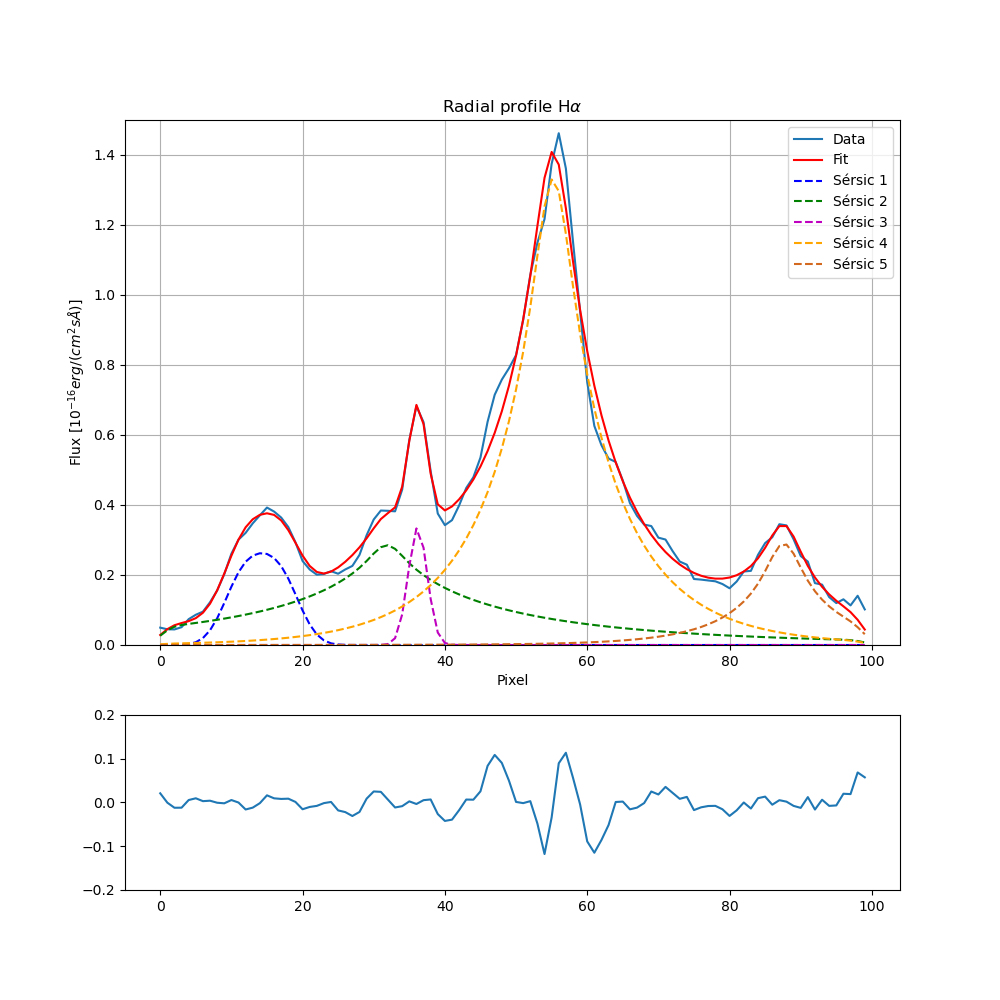

In [44]:
save_params_diff(best_params, radial_profile_HA, real_errors_HA, sigmas[0],
    x_axes, n_component, line_name="Halpha_diff", output_prefix="fit")

plot_diff(x_axes, best_params, radial_profile_HA, sigmas[0], r"Radial profile H$\alpha$")
plt.savefig('Radial_profile_Halpha_diff')

In [12]:
#lower_bounds, upper_bounds = zip(*bounds)
#bounds_list = (list(lower_bounds), list(upper_bounds))
best_params = [0.1848, 4.0381, 0.3281, 14.2530,
0.0270, 48.0360, 1.4194, 31.8305,
0.0052, 1.0338, 5.0850, 36.1688,
0.2148, 15.0967, 1.1702, 55.1968,
0.0401, 13.3531, 1.2921, 87.6153]
params_curve_HA, covariance_HA = curve_fit(lambda x, *params: model_convolved(x, sigmas[0], *params), x_axes, radial_profile_HA, p0=best_params, 
                                           sigma = real_errors_HA) #, bounds = bounds_list) #, maxfev= 10000)

print("Optimize parameters with curve fit:")

chi2_reduced_HA, dof_HA, chi2_HA = save_params(params_curve_HA, covariance_HA, radial_profile_HA, real_errors_HA, sigmas[0],
    x_axes, n_component, line_name="Halpha", output_prefix="fit")

C:\Users\ISAFA\AppData\Local\Temp\ipykernel_9728\2024936992.py:11: RuntimeWarning: invalid value encountered in power
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))
C:\Users\ISAFA\AppData\Local\Temp\ipykernel_9728\2024936992.py:24: RuntimeWarning: Use of fft convolution on input with NAN or inf results in NAN or inf output. Consider using method='direct' instead.
  conv_profile = convolve(profile, kernel, mode='same')


Optimize parameters with curve fit:
Sérsic 1: I_e=0.1872, r_e=4.0373, n=0.3328, x_0=14.3362
Sérsic 2: I_e=0.0133, r_e=86.9668, n=1.8601, x_0=31.5869
Sérsic 3: I_e=0.0059, r_e=0.1668, n=5.2476, x_0=36.1688
Sérsic 4: I_e=0.2304, r_e=14.1274, n=1.1142, x_0=54.9928
Sérsic 5: I_e=0.0198, r_e=24.4185, n=1.7330, x_0=87.6167
[3.12113376e-02 4.23689237e-01 1.32299998e-01 2.64266296e-01
 1.57539908e-02 9.73861907e+01 6.95484568e-01 9.68634417e-01
 1.14609177e+03 1.46997188e+04 2.72421768e+05 5.39751641e+00
 3.27335196e-02 2.00364068e+00 9.63939142e-02 1.12744100e-01
 2.88258731e-02 3.45272210e+01 9.34821687e-01 2.99483677e-01]
0.5404731618950543


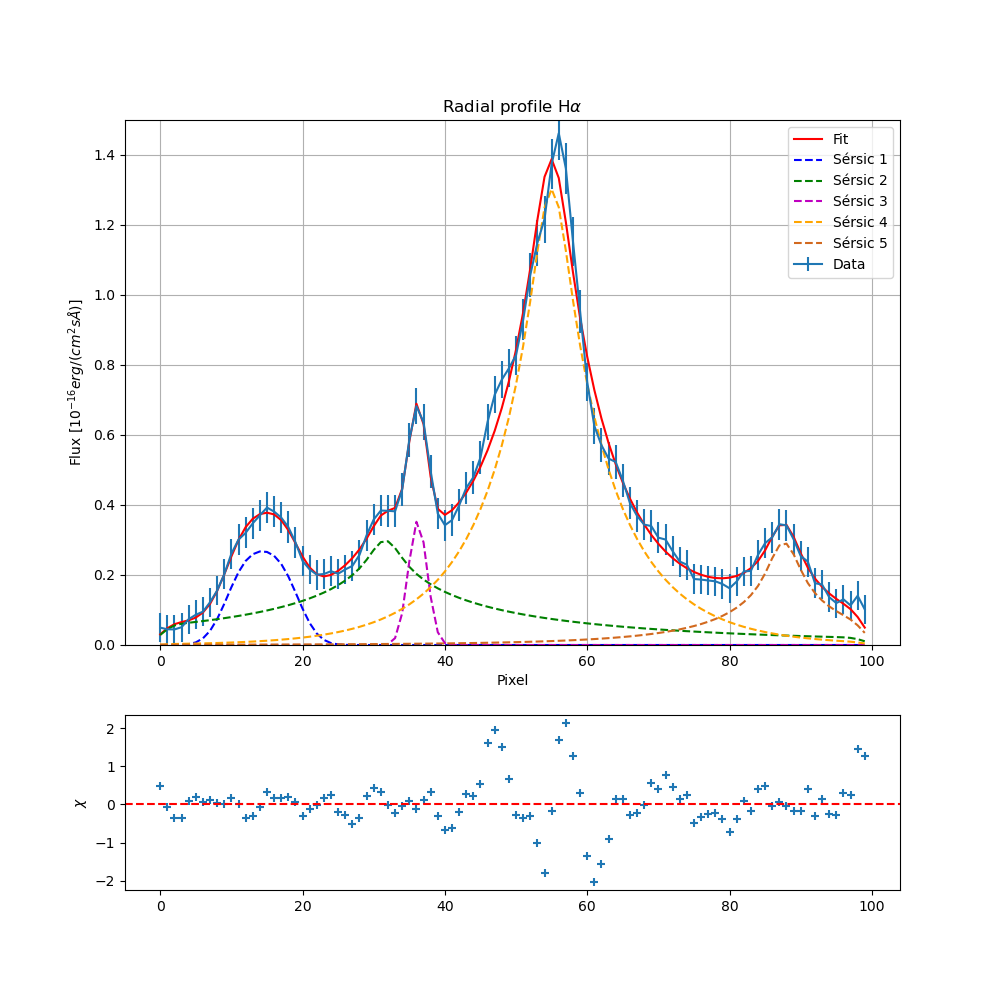

In [13]:
plot_curve(x_axes, params_curve_HA, radial_profile_HA, real_errors_HA, sigmas[0], r"Radial profile H$\alpha$")
plt.savefig('Radial_profile_Halpha_curve')

In [28]:
fit_HA = pd.read_csv("Halpha_fit.csv", index_col=0)
x_0_HA = fit_HA.iloc[3].values
bounds_HA = [
    (0, 1),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (x_0_HA[0]-seeing[-1]/2, x_0_HA[0]+seeing[-1]/2),   # x_0: circa la posizione di Halpha

    (0, 1),
    (0, 5),
    (0.1, 10),
    (x_0_HA[1]-seeing[-1]/2, x_0_HA[1]+seeing[-1]/2),

    (0, 1),
    (0, 5),
    (0.1, 10),
    (x_0_HA[2]-seeing[-1]/2, x_0_HA[2]+seeing[-1]/2),

    (0, 1),
    (0, 50),
    (0.1, 10),
    (x_0_HA[3]-seeing[-1]/2, x_0_HA[3]+seeing[-1]/2),

    (0, 1),
    (0, 50),
    (0.1, 10),
    (x_0_HA[4]-seeing[-1]/2, x_0_HA[4]+seeing[-1]/2),
]

bounds_HB = [
    (0, 1),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (11.5, 13),   # x_0: circa la posizione di Halpha

    (0, 1),
    (0, 10),
    (0.1, 10),
    (27, 29),

    (0, 1),
    (1, 5),
    (0.1, 10),
    (32, 34),

    (0, 1),
    (0, 50),
    (0.1, 10),
    (52, 54),

    (0, 1),
    (0, 50),
    (0.1, 10),
    (83, 85),
]

## H$\beta$

Text(0.5, 1.0, 'H$\\beta$')

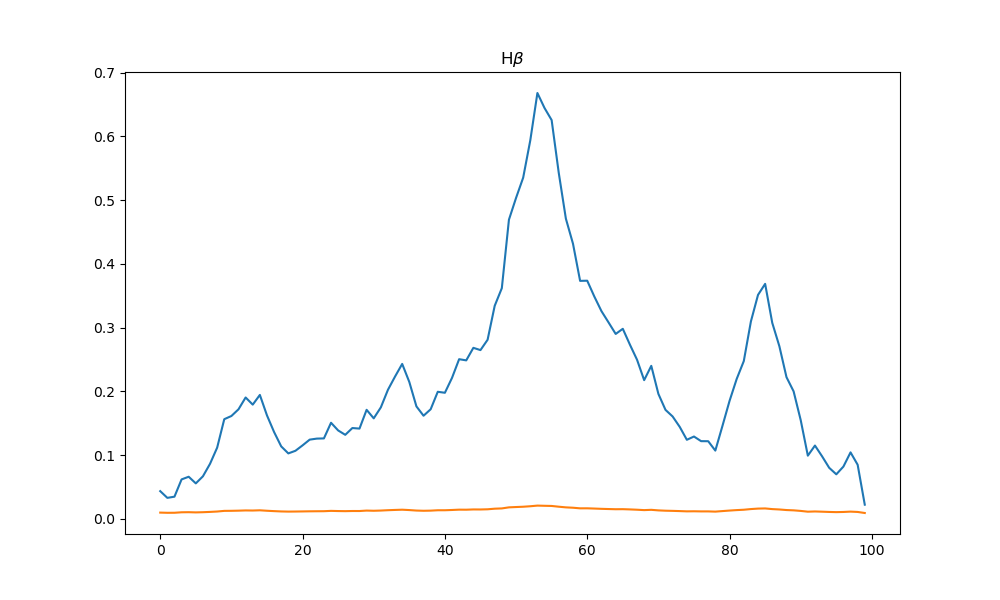

In [29]:
mask_HB = (wv > l_HB-8)*(wv < l_HB+8)
image_HB = image_cut[:, mask_HB] 
image_error_HB = image_error_cut[:, mask_HB]
radial_profile_HB = np.sum(image_HB, axis = 1)
radial_profile_error_HB = np.sqrt(np.sum(image_error_HB**2, axis = 1))
real_errors_HB = np.sqrt(radial_profile_error_HB**2+(sky_err[2])**2+(0.04*radial_profile_HB)**2)

plt.figure(figsize=(10, 6))
x_axes = np.arange(0, 100, 1)
plt.plot(x_axes, radial_profile_HB)
plt.plot(x_axes, radial_profile_error_HB)
plt.title(r'H$\beta$')

In [30]:
# Bounds:
bounds = bounds_HB

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_HB, sigmas[1])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 206.65125787235505
differential_evolution step 2: f(x)= 66.13365542212121
differential_evolution step 3: f(x)= 57.37297415405139
differential_evolution step 4: f(x)= 57.37297415405139
differential_evolution step 5: f(x)= 35.77619856345669
differential_evolution step 6: f(x)= 13.908554031651299
differential_evolution step 7: f(x)= 13.908554031651299
differential_evolution step 8: f(x)= 8.10632551456448
differential_evolution step 9: f(x)= 8.10632551456448
differential_evolution step 10: f(x)= 6.741087700289391
differential_evolution step 11: f(x)= 3.417846378839552
differential_evolution step 12: f(x)= 3.417846378839552
differential_evolution step 13: f(x)= 3.417846378839552
differential_evolution step 14: f(x)= 2.566243588060391
differential_evolution step 15: f(x)= 2.0178750932313743
differential_evolution step 16: f(x)= 1.5800856142774864
differential_evolution step 17: f(x)= 1.5800856142774864
differential_evolution step 18: f(x)= 1.5800856142774

Sérsic 1: I_e=0.0452, r_e=5.5435, n=0.8510, x_0=12.1563
Sérsic 2: I_e=0.0400, r_e=5.5170, n=0.1057, x_0=27.1984
Sérsic 3: I_e=0.0021, r_e=1.0301, n=4.4818, x_0=33.6437
Sérsic 4: I_e=0.0477, r_e=42.0006, n=1.6202, x_0=53.6563
Sérsic 5: I_e=0.0206, r_e=11.4123, n=1.9602, x_0=84.8984


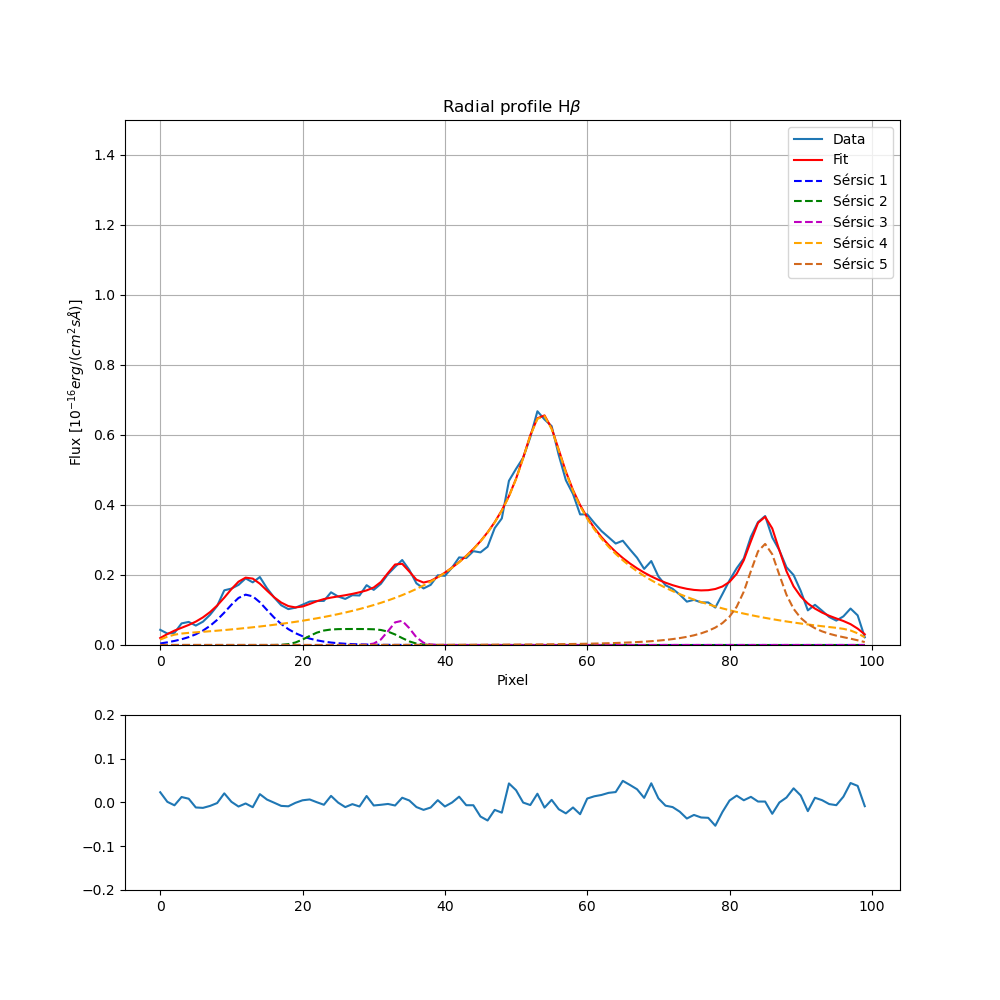

In [31]:
save_params_diff(best_params, radial_profile_HB, real_errors_HB, sigmas[1],
    x_axes, n_component, line_name="HBeta", output_prefix="fit")
plot_diff(x_axes, best_params, radial_profile_HB, sigmas[1], r"Radial profile H$\beta$")
plt.savefig('Radial_profile_Hbeta_diff')

In [32]:
lower_bounds, upper_bounds = zip(*bounds)
bounds_list = (list(lower_bounds), list(upper_bounds))
params_curve_HB, covariance_HB = curve_fit(lambda x, *params: model_convolved(x, sigmas[1], *params), 
                                           x_axes, radial_profile_HB, p0=result.x, sigma = real_errors_HB, bounds = bounds_list, maxfev = 10000)

print("Optimize parameters with curve fit:")
chi2_reduced_HB, dof_HB, chi2_HB = save_params(params_curve_HB, covariance_HB, radial_profile_HB, real_errors_HB, sigmas[1],
    x_axes, n_component, line_name="Hbeta", output_prefix="fit")

Optimize parameters with curve fit:
Sérsic 1: I_e=0.0458, r_e=5.4881, n=0.8425, x_0=12.1638
Sérsic 2: I_e=0.0389, r_e=5.7432, n=0.1039, x_0=27.1665
Sérsic 3: I_e=0.0020, r_e=1.0243, n=4.4741, x_0=33.6437
Sérsic 4: I_e=0.0476, r_e=42.0944, n=1.6216, x_0=53.6614
Sérsic 5: I_e=0.0209, r_e=11.2374, n=1.9522, x_0=84.9079
[3.28385258e-02 3.62070984e+00 5.18461479e-01 3.53198484e-01
 5.93037305e-02 1.79050494e+01 6.50302398e-01 8.16637857e+00
 2.41519717e+00 6.86267503e+02 8.26757518e+03 5.59164443e-01
 2.36235059e-02 2.21539106e+01 3.00890339e-01 1.34135342e-01
 3.62860555e-02 1.71836178e+01 1.22453257e+00 1.48895661e-01]
0.24376152513017296


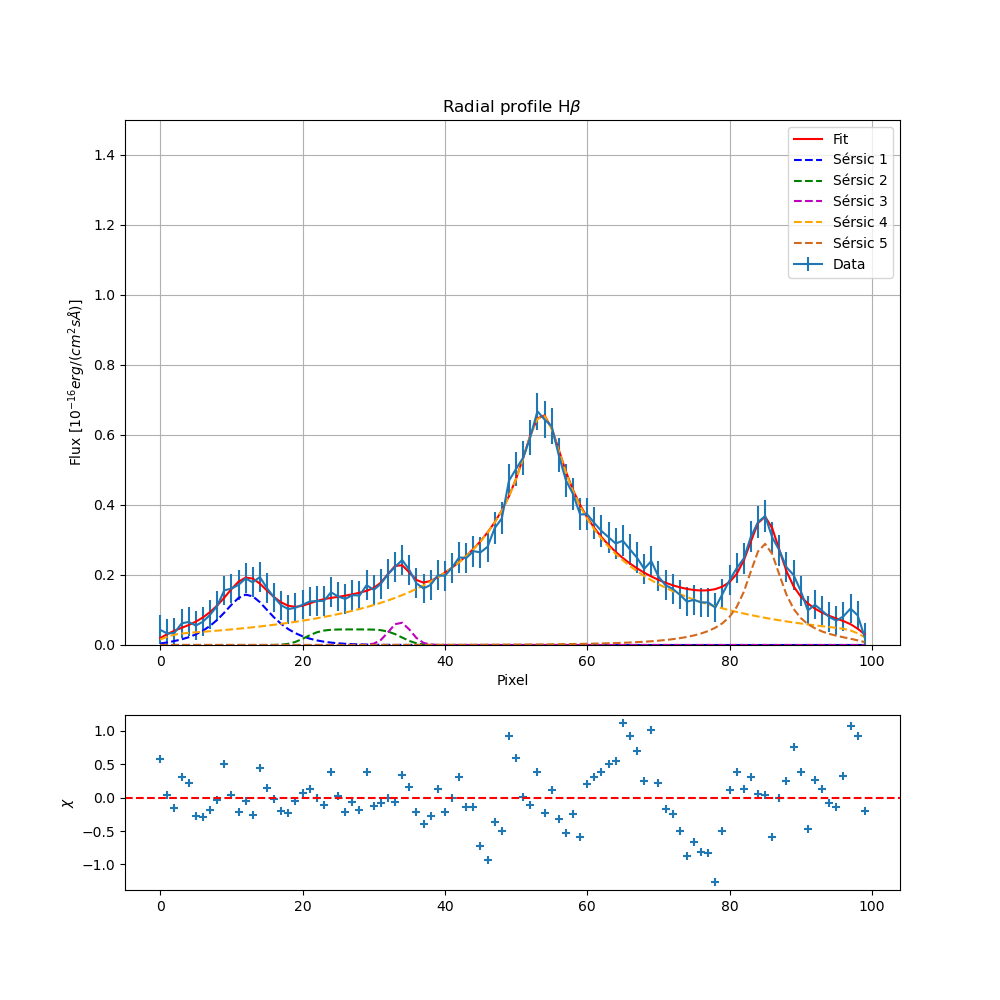

In [33]:
# Plots:
plot_curve(x_axes, params_curve_HB, radial_profile_HB, real_errors_HB, sigmas[1], r"Radial profile H$\beta$")
plt.savefig('Radial_profile_Hbeta_curve')

## [NII]

Text(0.5, 1.0, '[NII]')

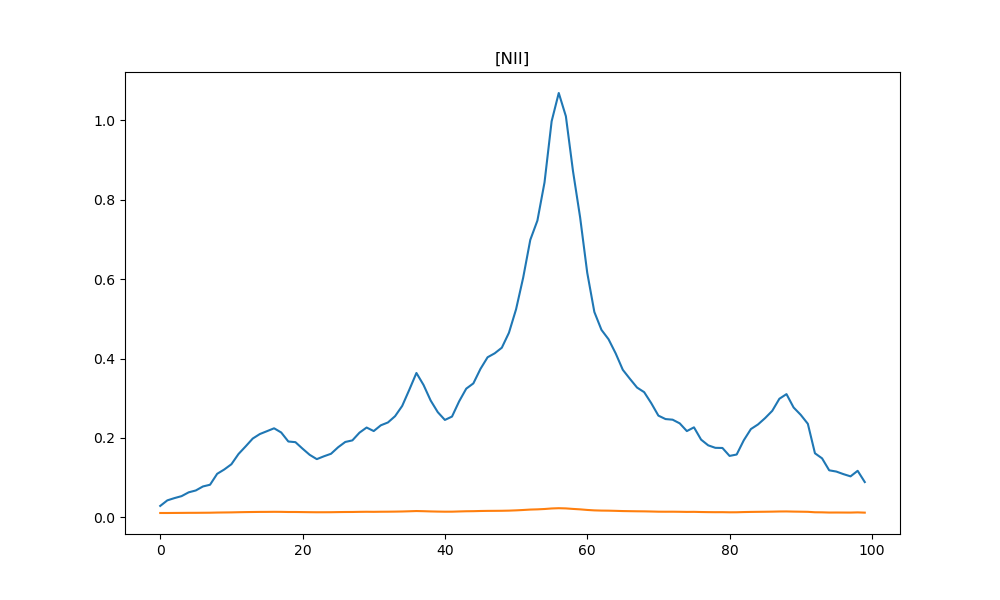

In [59]:
mask_NII = (wv > l_NII-8)*(wv < l_NII+8)
image_NII = image_cut[:, mask_NII]
image_error_NII = image_error_cut[:, mask_NII]
radial_profile_NII = np.sum(image_NII, axis = 1)
radial_profile_error_NII = np.sqrt(np.sum(image_error_NII**2, axis = 1))
real_errors_NII = np.sqrt(radial_profile_error_NII**2+(sky_err[2])**2+(0.04*radial_profile_NII)**2)

plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_NII)
plt.plot(x_axes, radial_profile_error_NII)
plt.title(r'[NII]')

In [65]:
# Bounds:
bounds = bounds_HA
# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_NII, sigmas[2])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 202.3135266873534
differential_evolution step 2: f(x)= 45.81867784079851
differential_evolution step 3: f(x)= 23.796586151800543
differential_evolution step 4: f(x)= 20.534177513968363
differential_evolution step 5: f(x)= 5.381581342178832
differential_evolution step 6: f(x)= 5.381581342178832
differential_evolution step 7: f(x)= 5.381581342178832
differential_evolution step 8: f(x)= 5.381581342178832
differential_evolution step 9: f(x)= 3.403809157702885
differential_evolution step 10: f(x)= 3.403809157702885
differential_evolution step 11: f(x)= 3.403809157702885
differential_evolution step 12: f(x)= 3.403809157702885
differential_evolution step 13: f(x)= 3.403809157702885
differential_evolution step 14: f(x)= 3.403809157702885
differential_evolution step 15: f(x)= 3.403809157702885
differential_evolution step 16: f(x)= 3.403809157702885
differential_evolution step 17: f(x)= 3.403809157702885
differential_evolution step 18: f(x)= 3.403809157702885

Sérsic 1: I_e=0.0379, r_e=8.6375, n=0.9517, x_0=15.1472
Sérsic 2: I_e=0.0580, r_e=3.9298, n=0.2786, x_0=30.2778
Sérsic 3: I_e=0.0955, r_e=1.1071, n=0.7136, x_0=36.2132
Sérsic 4: I_e=0.0496, r_e=50.0000, n=1.8895, x_0=55.8558
Sérsic 5: I_e=0.0530, r_e=5.9849, n=0.9576, x_0=87.9542


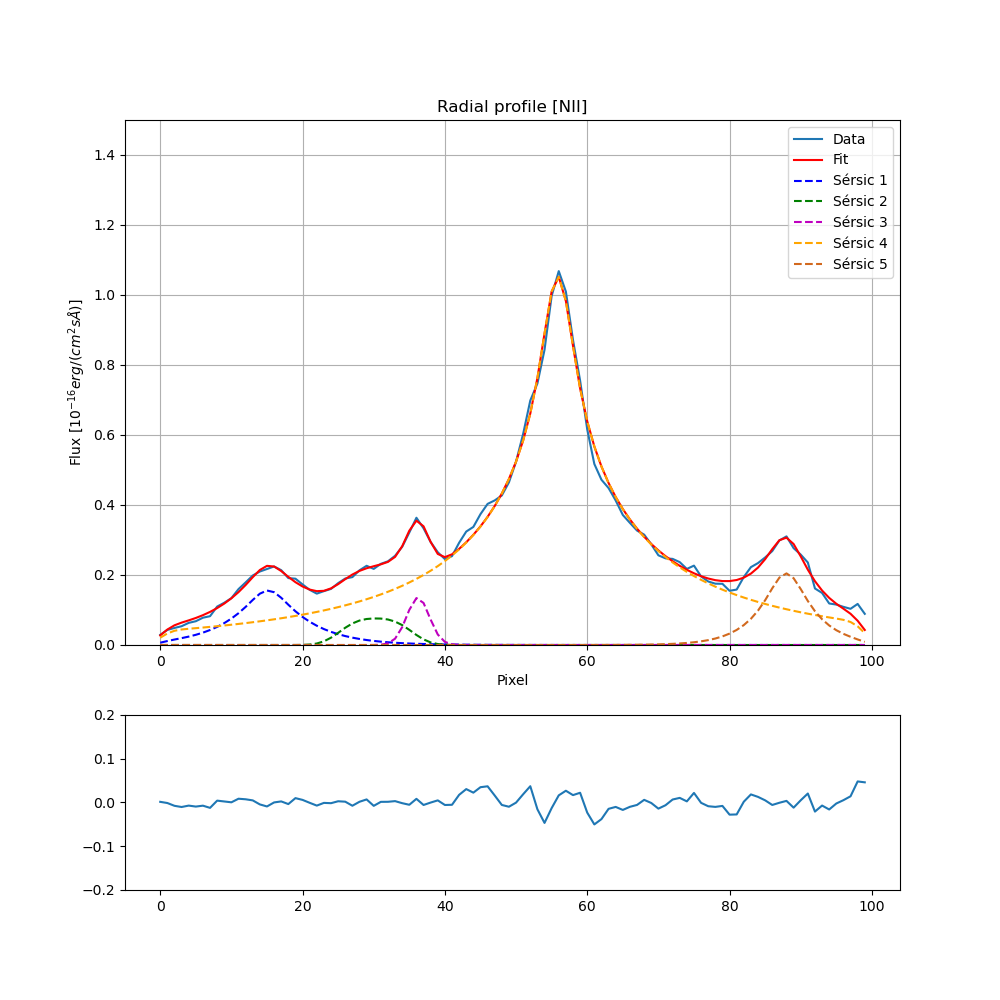

In [66]:
save_params_diff(best_params, radial_profile_NII, real_errors_NII, sigmas[2],
    x_axes, n_component, line_name="NII", output_prefix="fit")
plot_diff(x_axes, best_params, radial_profile_NII, sigmas[2], r"Radial profile [NII]")
plt.savefig('Radial_profile_NII_diff')

In [67]:
lower_bounds, upper_bounds = zip(*bounds)
bounds_list = (list(lower_bounds), list(upper_bounds))
params_curve_NII, covariance_NII = curve_fit(lambda x, *params: model_convolved(x, sigmas[2], *params), x_axes, radial_profile_NII, 
                                             p0=result.x, sigma = real_errors_NII, bounds = bounds_list, maxfev=10000)

print("Optimize parameters with curve fit:")
chi2_reduced_NII, dof_NII, chi2_NII = save_params(params_curve_NII, covariance_NII, radial_profile_NII, real_errors_NII, sigmas[2],
    x_axes, n_component, line_name="NII", output_prefix="fit")

Optimize parameters with curve fit:
Sérsic 1: I_e=0.0605, r_e=6.1996, n=0.6498, x_0=15.1018
Sérsic 2: I_e=0.0652, r_e=3.9973, n=0.2161, x_0=30.1613
Sérsic 3: I_e=0.0092, r_e=3.8591, n=2.7512, x_0=36.2431
Sérsic 4: I_e=0.0496, r_e=50.0000, n=1.8873, x_0=55.8196
Sérsic 5: I_e=0.0507, r_e=6.1734, n=0.9874, x_0=87.9593
[1.61429844e-02 1.48337904e+00 1.87773316e-01 3.13646198e-01
 1.71053609e-02 1.17315665e+00 2.24037776e-01 1.43964333e+00
 1.32391619e-01 3.02868693e+01 3.03564046e+01 2.16264181e-02
 1.18872649e-02 1.13522371e+01 1.49254488e-01 6.65693140e-02
 2.18121333e-02 2.33784159e+00 3.07967164e-01 1.76864672e-01]
0.14737199869387493


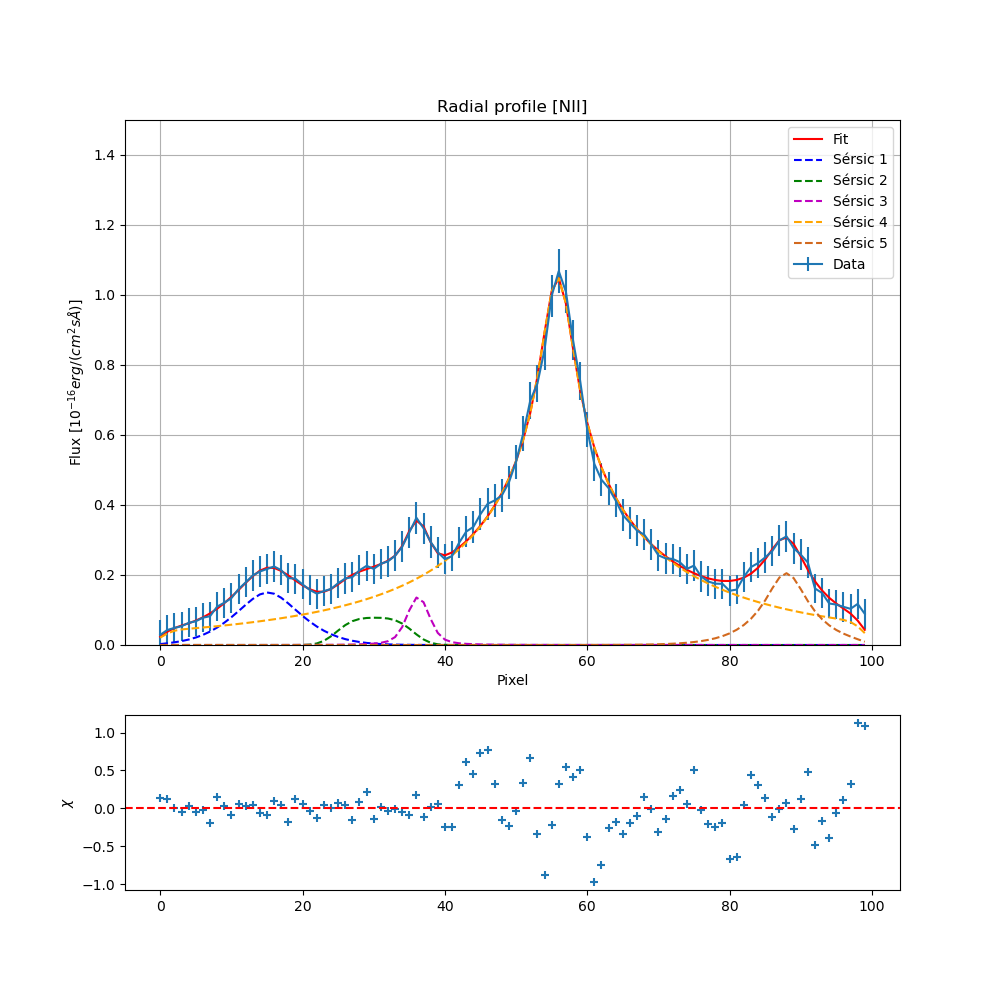

In [68]:
plot_curve(x_axes, params_curve_NII, radial_profile_NII, real_errors_NII, sigmas[2], r"Radial profile [NII]")
plt.savefig('Radial_profile_NII_curve')

## [SII]

Text(0.5, 1.0, '[SII]')

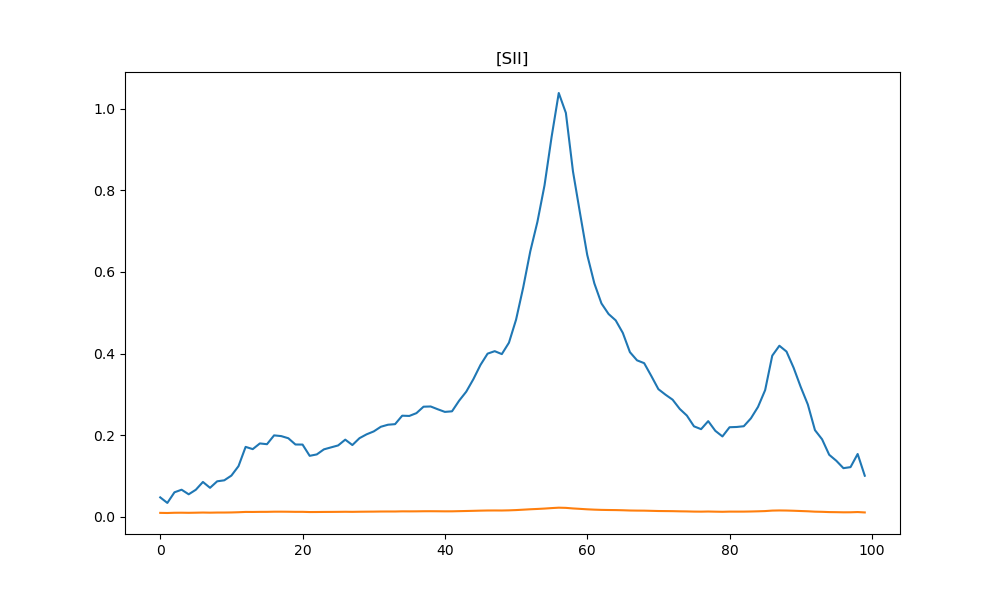

In [69]:
mask_SII = (wv > l_SII-8)*(wv < l_SII+8)
x_axes = np.arange(0, 100, 1)
image_SII = image_cut[:, mask_SII] 
image_error_SII = image_error_cut[:, mask_SII]
radial_profile_SII = np.sum(image_SII, axis = 1)
radial_profile_error_SII = np.sqrt(np.sum(image_error_SII**2, axis = 1))
real_errors_SII = np.sqrt(radial_profile_error_SII**2+(sky_err[2])**2+(0.04*radial_profile_SII)**2)

plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_SII)
plt.plot(x_axes, radial_profile_error_SII)
plt.title(r'[SII]')

In [70]:
# Bounds:
bounds = bounds_HA
# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_SII, sigmas[3])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 96.98114841732526
differential_evolution step 2: f(x)= 60.06713434978395
differential_evolution step 3: f(x)= 60.06713434978395
differential_evolution step 4: f(x)= 26.663122161418183
differential_evolution step 5: f(x)= 18.053272839749084
differential_evolution step 6: f(x)= 18.053272839749084
differential_evolution step 7: f(x)= 18.053272839749084
differential_evolution step 8: f(x)= 7.740889744778265
differential_evolution step 9: f(x)= 5.269024591643468
differential_evolution step 10: f(x)= 2.0821808664030943
differential_evolution step 11: f(x)= 2.0821808664030943
differential_evolution step 12: f(x)= 2.0821808664030943
differential_evolution step 13: f(x)= 2.0821808664030943
differential_evolution step 14: f(x)= 2.0821808664030943
differential_evolution step 15: f(x)= 1.7172237816869451
differential_evolution step 16: f(x)= 1.7172237816869451
differential_evolution step 17: f(x)= 1.7172237816869451
differential_evolution step 18: f(x)= 1.71722

Sérsic 1: I_e=0.0116, r_e=22.4615, n=1.5036, x_0=15.8295
Sérsic 2: I_e=0.2497, r_e=0.1156, n=1.0033, x_0=30.9488
Sérsic 3: I_e=0.6572, r_e=0.0350, n=2.1324, x_0=35.6867
Sérsic 4: I_e=0.0541, r_e=49.9430, n=1.7845, x_0=56.1704
Sérsic 5: I_e=0.0224, r_e=14.5231, n=1.8075, x_0=87.6890


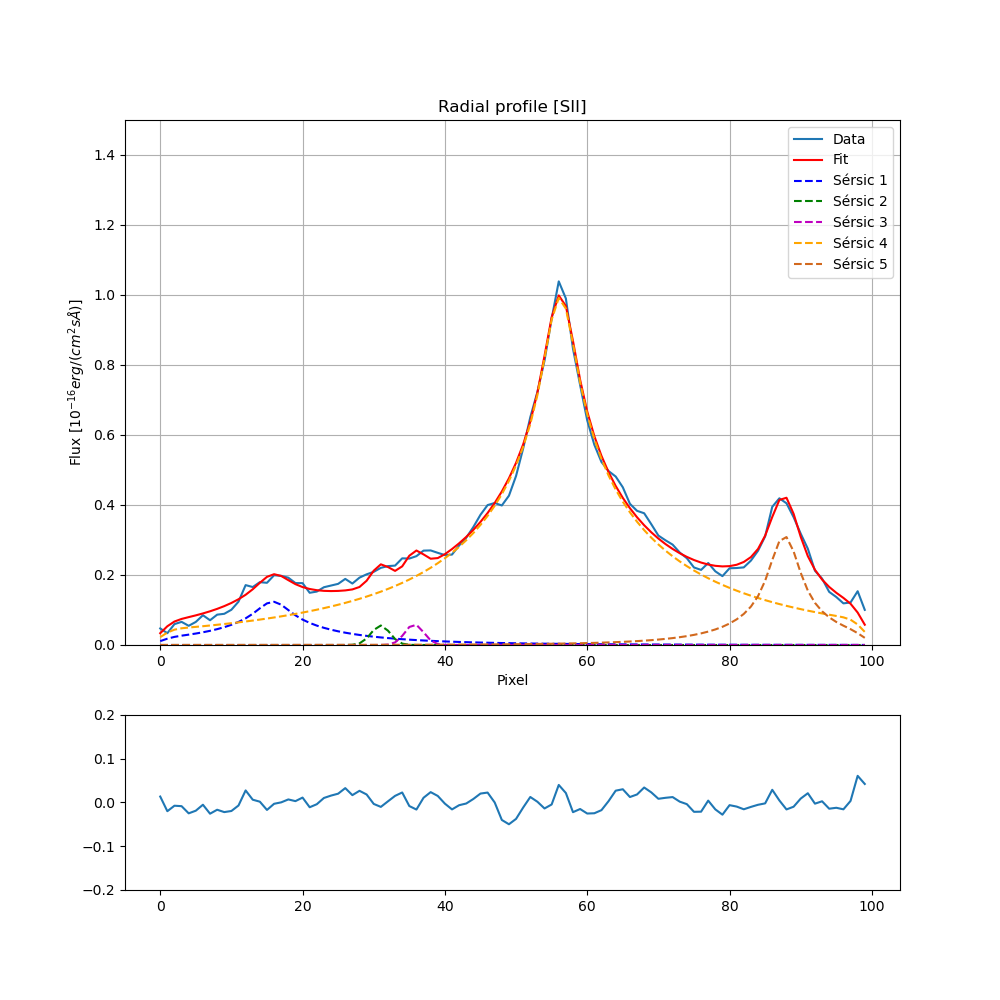

In [71]:
save_params_diff(best_params, radial_profile_SII, real_errors_SII, sigmas[3],
    x_axes, n_component, line_name="SII", output_prefix="fit")
plot_diff(x_axes, best_params, radial_profile_SII, sigmas[3], r"Radial profile [SII]")
plt.savefig('Radial_profile_SII_diff')

In [72]:
lower_bounds, upper_bounds = zip(*bounds)
bounds_list = (list(lower_bounds), list(upper_bounds))
params_curve_SII, covariance_SII = curve_fit(lambda x, *params: model_convolved(x, sigmas[3], *params), x_axes, 
                                             radial_profile_SII, p0=result.x, sigma = real_errors_SII, bounds = bounds_list)

print("Optimize parameters with curve fit:")
chi2_reduced_SII, dof_SII, chi2_SII = save_params(params_curve_SII, covariance_SII, radial_profile_SII, real_errors_SII, sigmas[3],
    x_axes, n_component, line_name="SII", output_prefix="fit")

Optimize parameters with curve fit:
Sérsic 1: I_e=0.0444, r_e=6.4578, n=0.6917, x_0=15.8372
Sérsic 2: I_e=0.0492, r_e=4.9981, n=0.2331, x_0=31.6259
Sérsic 3: I_e=0.6469, r_e=0.0017, n=2.1479, x_0=35.6973
Sérsic 4: I_e=0.0539, r_e=49.9999, n=1.7867, x_0=56.1718
Sérsic 5: I_e=0.0142, r_e=20.5337, n=2.1341, x_0=87.6775
[1.94468502e-02 3.19504897e+00 3.30207358e-01 4.62247362e-01
 1.76416396e-02 7.12271582e-01 2.76443961e-01 1.17536742e+00
 6.30802238e+05 2.26762063e+03 1.23501163e+06 1.70852511e+03
 2.40850928e-02 2.09678919e+01 3.02359067e-01 5.40920883e-02
 1.56831810e-02 2.14861402e+01 7.49334898e-01 1.26056477e-01]
0.17877297193236993


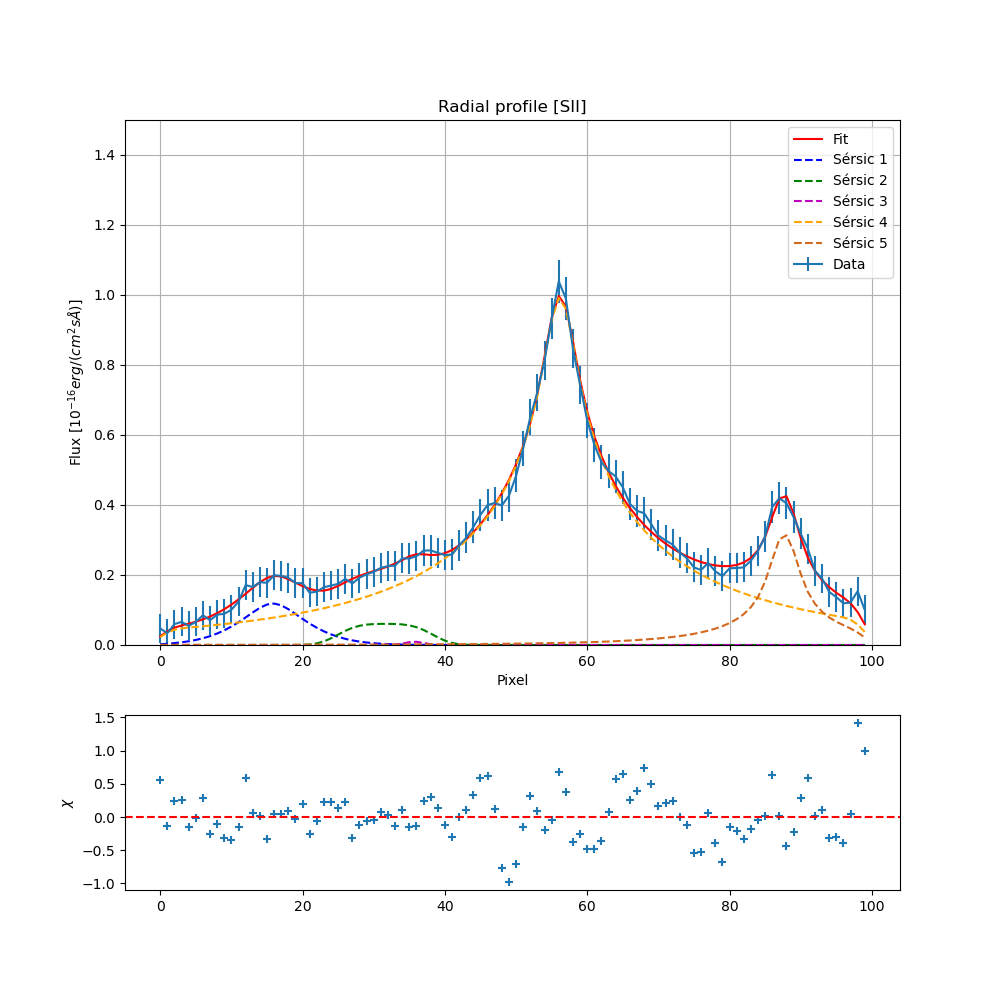

In [73]:
# Plots:
plot_curve(x_axes, params_curve_SII, radial_profile_SII, real_errors_SII, sigmas[3], r"Radial profile [SII]")
plt.savefig('Radial_profile_SII_curve')

## [OIII]

Text(0.5, 1.0, '[OIII]')

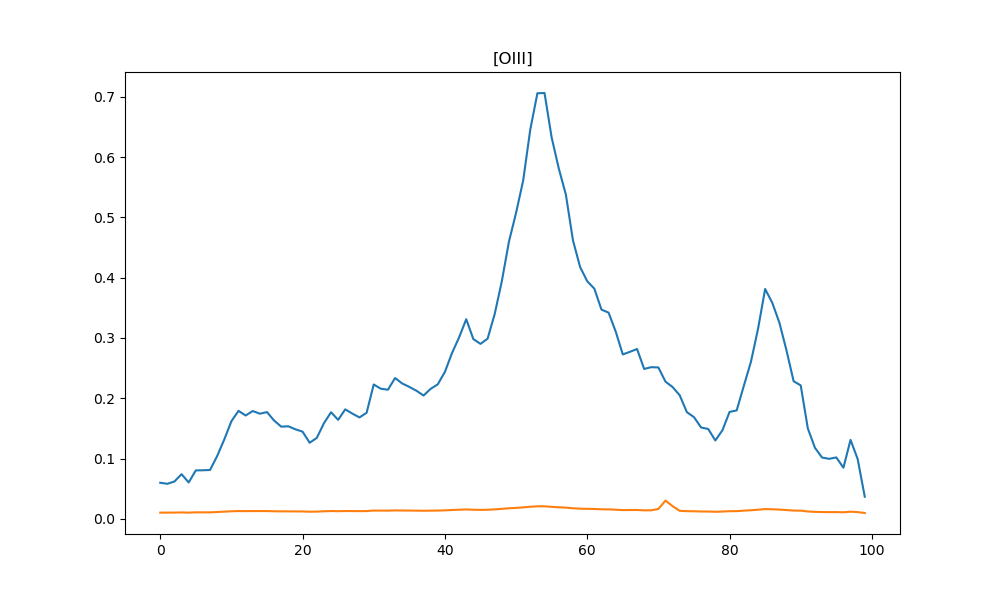

In [74]:
mask_OIII = (wv > l_OIII-8)*(wv < l_OIII+8)
image_OIII = image_cut[:, mask_OIII] 
image_error_OIII = image_error_cut[:, mask_OIII]
radial_profile_OIII = np.sum(image_OIII, axis = 1)
radial_profile_error_OIII = np.sqrt(np.sum(image_error_OIII**2, axis = 1))
real_errors_OIII = np.sqrt(radial_profile_error_OIII**2+(sky_err[2])**2+(0.04*radial_profile_OIII)**2)

plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_OIII)
plt.plot(x_axes, radial_profile_error_OIII)
plt.title(r'[OIII]')

In [75]:
# Bounds:
bounds = bounds_HB

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_OIII, sigmas[4])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 28.842803097559262
differential_evolution step 2: f(x)= 28.842803097559262
differential_evolution step 3: f(x)= 28.842803097559262
differential_evolution step 4: f(x)= 28.842803097559262
differential_evolution step 5: f(x)= 18.55556352382674
differential_evolution step 6: f(x)= 18.55556352382674
differential_evolution step 7: f(x)= 10.325657864619254
differential_evolution step 8: f(x)= 10.325657864619254
differential_evolution step 9: f(x)= 10.325657864619254
differential_evolution step 10: f(x)= 7.836167111751429
differential_evolution step 11: f(x)= 4.601375434218601
differential_evolution step 12: f(x)= 4.601375434218601
differential_evolution step 13: f(x)= 4.601375434218601
differential_evolution step 14: f(x)= 4.601375434218601
differential_evolution step 15: f(x)= 4.601375434218601
differential_evolution step 16: f(x)= 4.601375434218601
differential_evolution step 17: f(x)= 4.601375434218601
differential_evolution step 18: f(x)= 4.0478572734

Sérsic 1: I_e=0.0168, r_e=11.5413, n=1.3319, x_0=12.5289
Sérsic 2: I_e=0.0234, r_e=8.3487, n=0.5277, x_0=27.5502
Sérsic 3: I_e=0.0437, r_e=1.3875, n=0.1164, x_0=32.3466
Sérsic 4: I_e=0.0438, r_e=49.7867, n=1.6918, x_0=53.6956
Sérsic 5: I_e=0.0038, r_e=48.1753, n=3.0543, x_0=85.0000


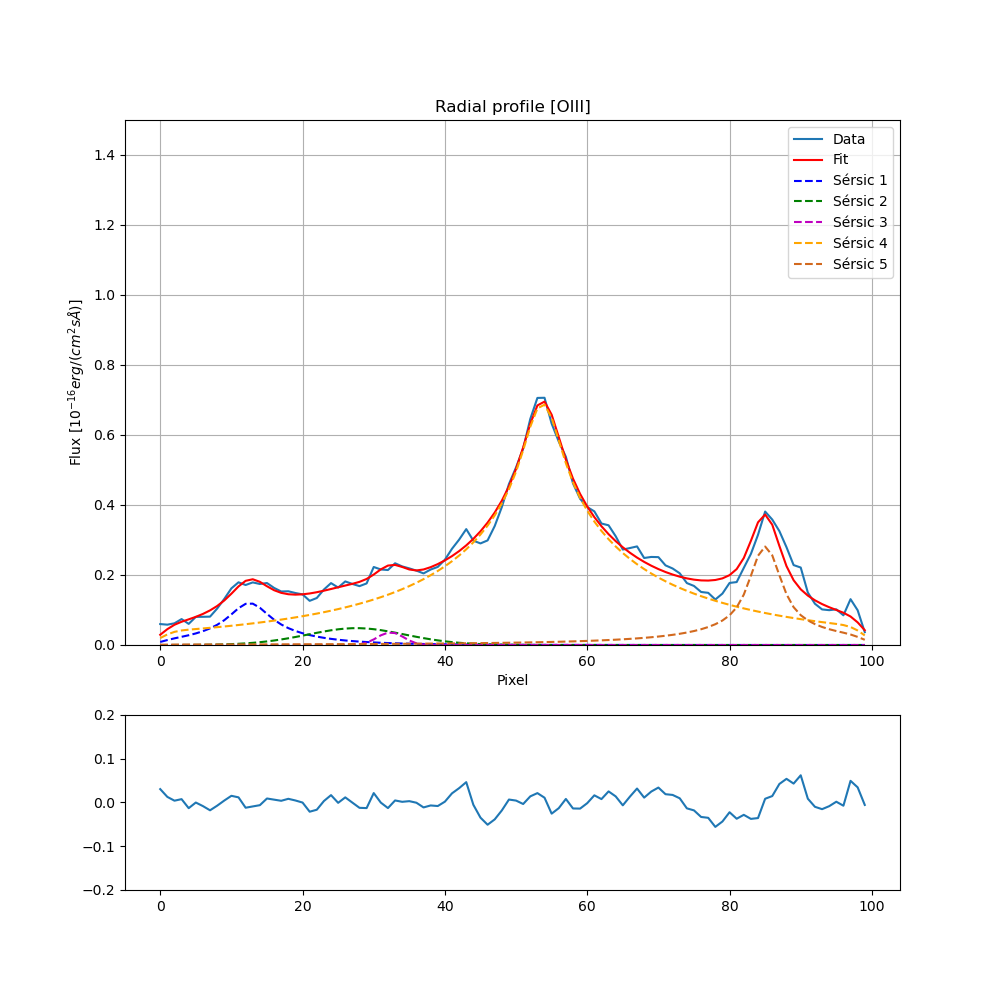

In [76]:
save_params_diff(best_params, radial_profile_OIII, real_errors_OIII, sigmas[4],
    x_axes, n_component, line_name="OIII", output_prefix="fit")
plot_diff(x_axes, best_params, radial_profile_OIII, sigmas[4], r"Radial profile [OIII]")
plt.savefig('Radial_profile_OIII_diff')

In [77]:
lower_bounds, upper_bounds = zip(*bounds)
bounds_list = (list(lower_bounds), list(upper_bounds))
params_curve_OIII, covariance_OIII = curve_fit(lambda x, *params: model_convolved(x, sigmas[4], *params), x_axes, radial_profile_OIII, 
                                               p0=result.x, sigma = real_errors_OIII, bounds = bounds_list, maxfev=10000)

print("Optimize parameters with curve fit:")
chi2_reduced_OIII, dof_OIII, chi2_OIII = save_params(params_curve_OIII, covariance_OIII, radial_profile_OIII, real_errors_OIII, sigmas[4],
    x_axes, n_component, line_name="OIII", output_prefix="fit")

Optimize parameters with curve fit:
Sérsic 1: I_e=0.0206, r_e=9.9090, n=1.1842, x_0=12.5193
Sérsic 2: I_e=0.0228, r_e=8.5727, n=0.5418, x_0=27.4562
Sérsic 3: I_e=0.0381, r_e=1.7798, n=0.1034, x_0=32.3061
Sérsic 4: I_e=0.0437, r_e=49.9942, n=1.6919, x_0=53.7209
Sérsic 5: I_e=0.0035, r_e=49.9338, n=3.1225, x_0=85.0000
[3.84280582e-02 1.65763226e+01 1.18607115e+00 8.03674375e-01
 4.55056094e-02 1.21830051e+01 1.06726710e+00 7.51225265e+00
 1.82177532e+00 1.17307948e+02 1.91351735e+01 1.30516685e+00
 3.09647378e-02 4.13019363e+01 4.34778878e-01 1.66735567e-01
 1.79269843e-02 2.38375563e+02 3.42516119e+00 1.85010361e-01]
0.32546208148916556


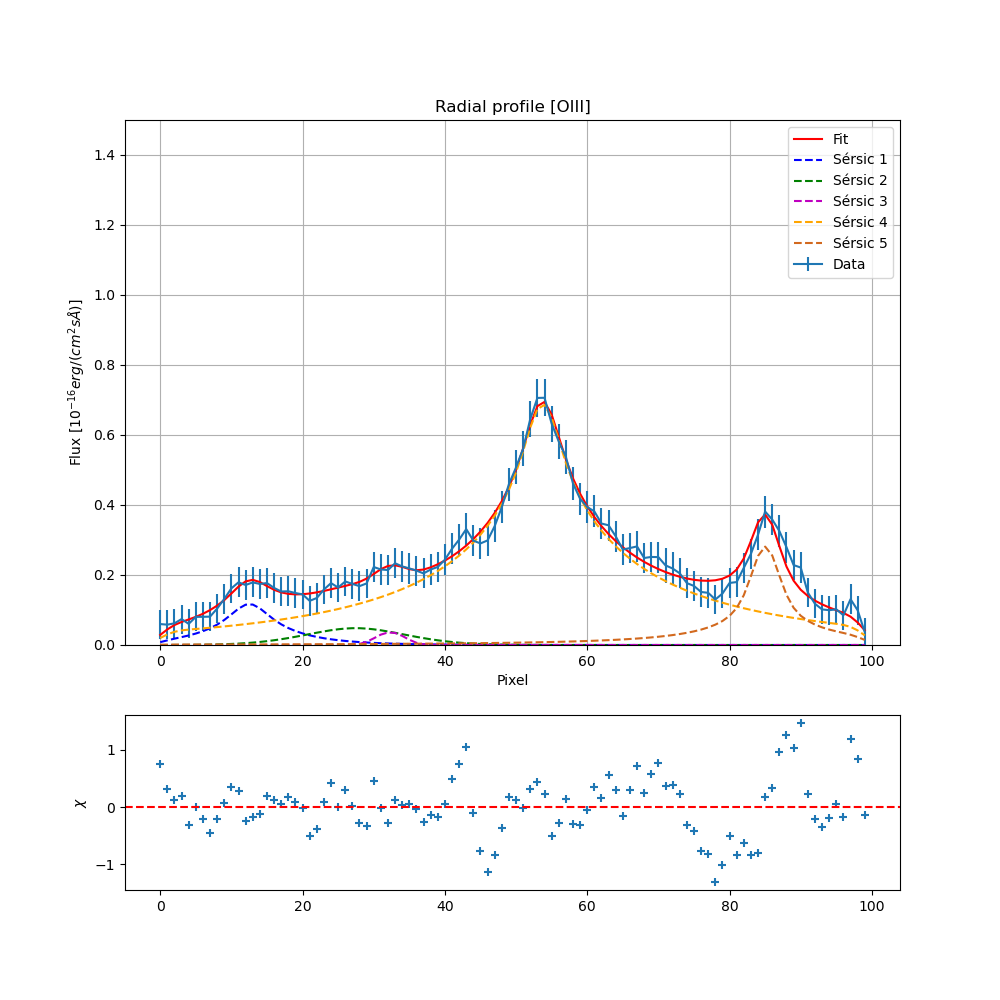

In [78]:
plot_curve(x_axes, params_curve_OIII, radial_profile_OIII, real_errors_OIII, sigmas[4], r"Radial profile [OIII]")
plt.savefig('Radial_profile_OIII_curve')

In [79]:
chi_red = [chi2_reduced_HA, chi2_reduced_HB, chi2_reduced_NII, chi2_reduced_SII, chi2_reduced_OIII]
dof = [dof_HA, dof_HB, dof_NII, dof_SII, dof_OIII]
chi = [chi2_HA, chi2_HB, chi2_NII, chi2_SII, chi2_OIII]

d1 = {'Name': ['Halpha', 'Hbeta', 'NII', 'SII', 'OIII'], 'Chi squared': chi,
      'Dof': dof, 'Chi reduced': chi_red}
df1 = pd.DataFrame(data=d1)
df1.to_csv("Chi_squared_curve_fit.csv", index= False)

## Continuum 1

Text(0.5, 1.0, 'Continuum 1')

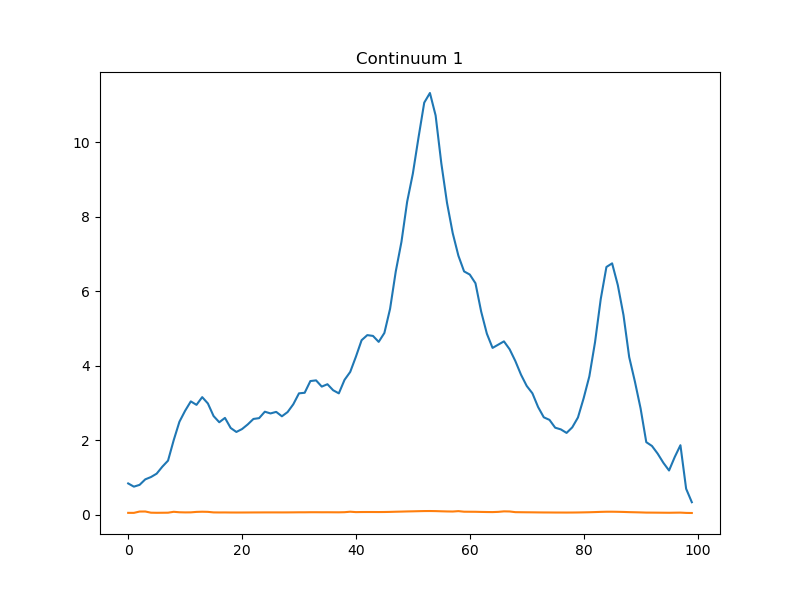

In [80]:
mask_continuum_1 = (wv > 4500)*(wv < 4800)
image_continuum_1 = image_cut[:, mask_continuum_1]
image_error_continuum_1 = image_error_cut[:, mask_continuum_1]
radial_profile_continuum_1 = np.sum(image_continuum_1, axis = 1)
radial_profile_error_continuum_1 = np.sqrt(np.sum(image_error_continuum_1**2, axis = 1))
real_errors_c1 = np.sqrt(radial_profile_error_continuum_1**2+(sky_err[2])**2+(0.04*radial_profile_continuum_1)**2)

x_axes = np.arange(0, 100, 1)
plt.figure(figsize=(8,6))
plt.plot(x_axes, radial_profile_continuum_1)
plt.plot(x_axes, radial_profile_error_continuum_1)
plt.title(r'Continuum 1')

In [81]:
# Bounds:
bounds = bounds_HA

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_continuum_1, sigmas[1])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 371.46225342495035
differential_evolution step 2: f(x)= 292.46929121594917
differential_evolution step 3: f(x)= 175.25120885151472
differential_evolution step 4: f(x)= 117.2883165490884
differential_evolution step 5: f(x)= 117.2883165490884
differential_evolution step 6: f(x)= 93.48297271006868
differential_evolution step 7: f(x)= 93.48297271006868
differential_evolution step 8: f(x)= 93.48297271006868
differential_evolution step 9: f(x)= 93.48297271006868
differential_evolution step 10: f(x)= 93.48297271006868
differential_evolution step 11: f(x)= 88.6662709209827
differential_evolution step 12: f(x)= 88.04479382437309
differential_evolution step 13: f(x)= 88.04479382437309
differential_evolution step 14: f(x)= 88.04479382437309
differential_evolution step 15: f(x)= 88.04479382437309
differential_evolution step 16: f(x)= 69.25836464875586
differential_evolution step 17: f(x)= 69.25836464875586
differential_evolution step 18: f(x)= 69.25836464875586

In [82]:
def plot_curve(x_axes, params_curve, radial_profile, radial_profile_err, sigma, title = ""):
    y_fit = model_convolved(x_axes, sigma, *params_curve)
    fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

    ax[0].errorbar(x_axes, radial_profile, radial_profile_err, label='Data')
    ax[0].plot(x_axes, y_fit, 'r-', label='Fit')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[0:4], sigma), 'b--', label='Sérsic 1')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[4:8], sigma), 'g--', label='Sérsic 2')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[8:12], sigma), 'm--', label='Sérsic 3')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[12:16], sigma), color='orange', linestyle='--', label='Sérsic 4')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[16:20], sigma), color = 'chocolate', linestyle='--', label='Sérsic 5')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[20:24], sigma), color = 'purple', linestyle='--', label='Sérsic 6')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[24:28], sigma), color = 'deeppink', linestyle='--', label='Sérsic 7')

    ax[0].set_xlabel("Pixel")
    ax[0].set_ylabel(r'Flux [$10^{-16} erg/(cm^2 s \AA )$]')
    ax[0].set_title(title)
    ax[0].legend()
    ax[0].grid(True)
    #ax[0].set_ylim(0, 30)
    #ax[0].tight_layout()
    
    ax[1].scatter(x_axes, (radial_profile - y_fit)/radial_profile_err, marker = '+')
    ax[1].axhline(0, color ='red', linestyle ='dashed')
    ax[1].set_ylabel(r'$\chi$')

def plot_diff(x_axes, best_params, radial_profile, sigma, title = ""):
    y_fit = model_convolved(x_axes, sigma, *best_params)

    fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

    ax[0].plot(x_axes, radial_profile, label='Data')
    ax[0].plot(x_axes, y_fit, 'r-', label='Fit')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[0:4], sigma), 'b--', label='Sérsic 1')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[4:8], sigma), 'g--', label='Sérsic 2')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[8:12], sigma), 'm--', label='Sérsic 3')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[12:16], sigma), color='orange', linestyle='--', label='Sérsic 4')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[16:20], sigma), color = 'chocolate', linestyle='--', label='Sérsic 5')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[20:24], sigma), color = 'purple', linestyle='--', label='Sérsic 6')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[24:28], sigma), color = 'deeppink', linestyle='--', label='Sérsic 7')

    ax[0].set_xlabel("Pixel")
    ax[0].set_ylabel(r'Flux [$10^{-16} erg/(cm^2 s \AA )$]')
    ax[0].set_title(title)
    ax[0].legend()
    ax[0].grid(True)
    #ax[0].set_ylim(0, 30)
    #ax[0].tight_layout()
    
    ax[1].plot(x_axes, radial_profile - y_fit)
    ax[1].set_ylim(-0.2, 0.2)

Sérsic 1: I_e=0.3595, r_e=12.6954, n=1.2034, x_0=12.7264
Sérsic 2: I_e=0.5381, r_e=5.0000, n=0.3778, x_0=30.1479
Sérsic 3: I_e=0.0000, r_e=4.5640, n=0.3490, x_0=36.8462
Sérsic 4: I_e=0.9796, r_e=40.0399, n=1.4813, x_0=53.4924
Sérsic 5: I_e=1.0000, r_e=6.0649, n=1.2145, x_0=86.0778


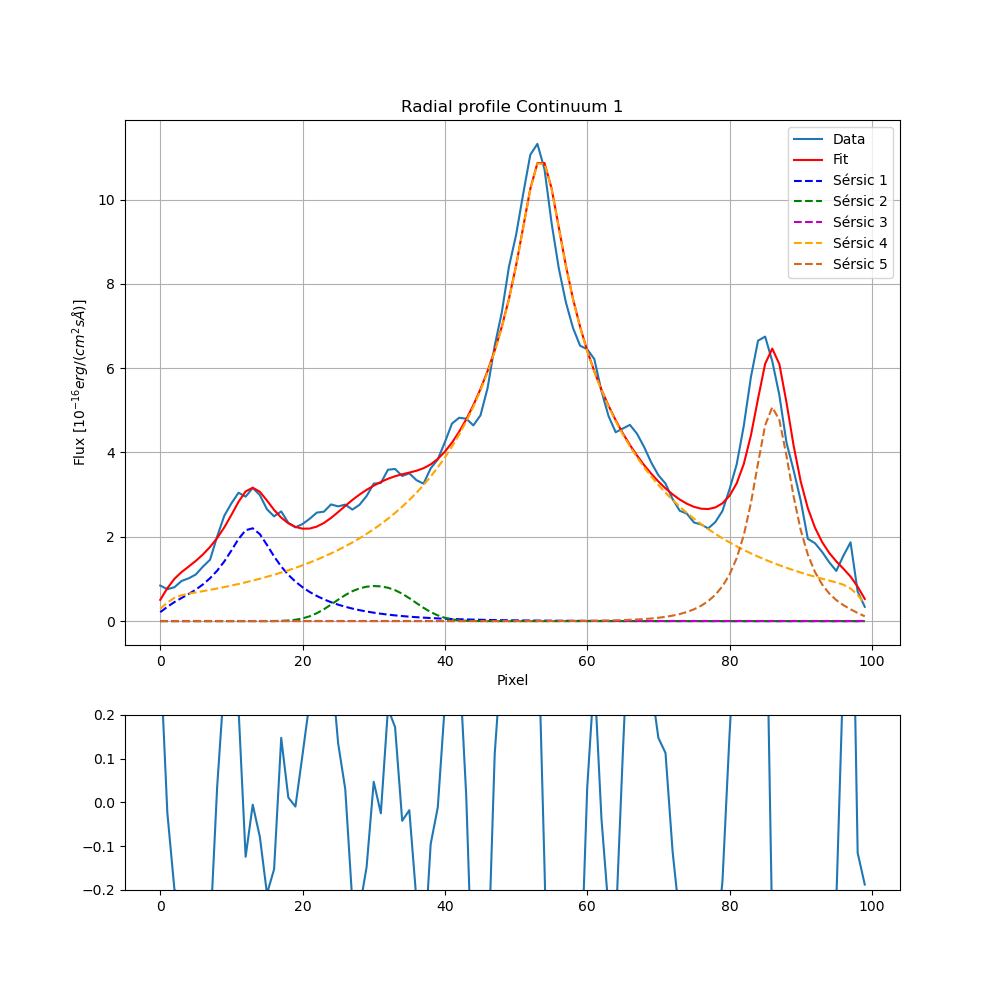

In [83]:
save_params_diff(best_params, radial_profile_continuum_1, real_errors_c1, sigmas[1],
    x_axes, n_component, line_name="Continuum_1", output_prefix="fit")
plot_diff(x_axes, best_params, radial_profile_continuum_1, sigmas[1], r"Radial profile Continuum 1")
plt.savefig('Radial_profile_continuum_1_diff')

In [84]:
lower_bounds, upper_bounds = zip(*bounds)
bounds_list = (list(lower_bounds), list(upper_bounds))

params_curve_continuum_1, covariance_continuum_1 = curve_fit(lambda x, *params: model_convolved(x, sigmas[1], *params), x_axes,
                                                             radial_profile_continuum_1, p0=result.x, sigma = real_errors_c1, bounds = bounds_list, maxfev=15000)
print("Optimize parameters with curve fit:")
chi2_reduced_continuum_1, dof_continuum_1, chi2_continuum_1 = save_params(params_curve_continuum_1, covariance_continuum_1, 
                                                                          radial_profile_continuum_1, real_errors_c1, sigmas[1],
                                                                          x_axes, n_component, line_name="Continuum_1", output_prefix="fit")

Optimize parameters with curve fit:
Sérsic 1: I_e=0.5021, r_e=8.5944, n=0.9882, x_0=12.9499
Sérsic 2: I_e=0.6115, r_e=5.0000, n=0.3147, x_0=30.1479
Sérsic 3: I_e=0.0000, r_e=2.0527, n=0.1085, x_0=35.4485
Sérsic 4: I_e=0.8992, r_e=43.6759, n=1.5225, x_0=53.4924
Sérsic 5: I_e=1.0000, r_e=5.0890, n=1.2379, x_0=86.0778
[3.77320349e-01 6.42312109e+00 5.33529224e-01 4.59222558e-01
 5.72481786e-01 1.92469885e+00 5.71723831e-01 3.87831392e+00
 1.00755581e+00 5.44673823e-15 6.28575433e-14 4.53439167e-14
 4.47755915e-01 2.07542460e+01 3.08929191e-01 2.77111481e-01
 9.77722468e-01 3.85107470e+00 7.46243380e-01 2.07112853e-01]
6.724708919255592


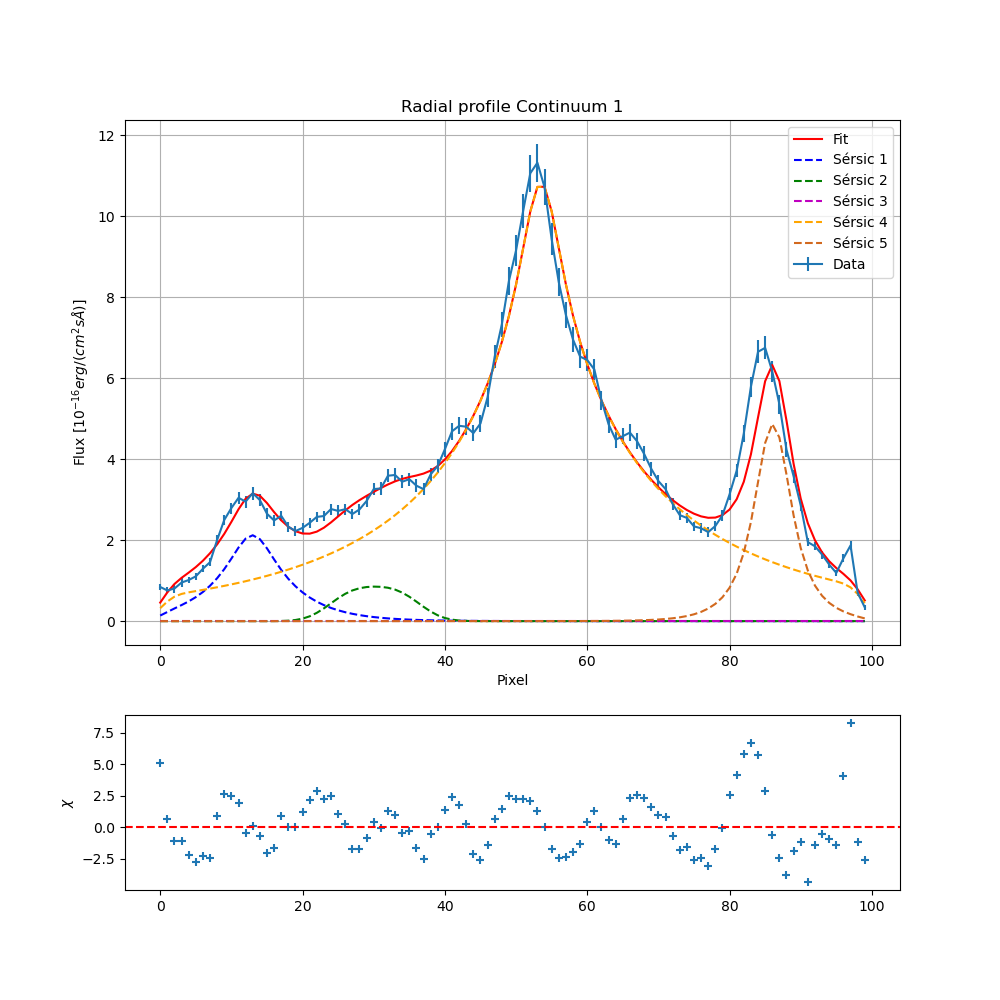

In [85]:
# Plots:
plot_curve(x_axes, params_curve_continuum_1, radial_profile_continuum_1, real_errors_c1, sigmas[1], r"Radial profile Continuum 1")
plt.savefig('Radial_profile_continuum_1_curve')

## Continuum 2 

Text(0.5, 1.0, 'Continuum 2')

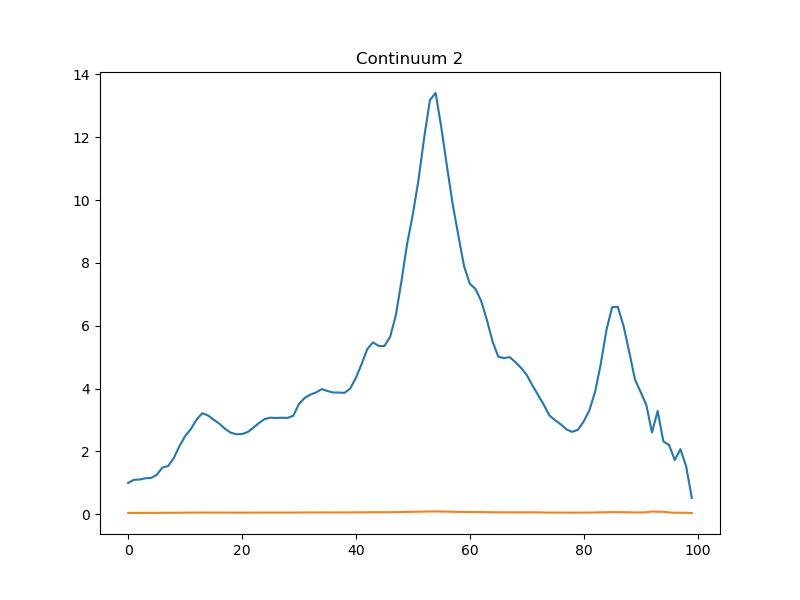

In [86]:
mask_continuum_2 = (wv > 5100)*(wv < 5400)
image_continuum_2 = image_cut[:, mask_continuum_2]
image_error_continuum_2 = image_error_cut[:, mask_continuum_2]
radial_profile_continuum_2 = np.sum(image_continuum_2, axis = 1)
radial_profile_error_continuum_2 = np.sqrt(np.sum(image_error_continuum_2**2, axis = 1))
real_errors_c2 = np.sqrt(radial_profile_error_continuum_2**2+(sky_err[2])**2+(0.04*radial_profile_continuum_2)**2)

x_axes = np.arange(0, 100, 1)
plt.figure(figsize=(8,6))
plt.plot(x_axes, radial_profile_continuum_2)
plt.plot(x_axes, radial_profile_error_continuum_2)
plt.title(r'Continuum 2')

In [87]:
# Bounds:
bounds = bounds_HA

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_continuum_2, sigmas[5])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 449.40230585469715
differential_evolution step 2: f(x)= 221.62834315804804
differential_evolution step 3: f(x)= 221.62834315804804
differential_evolution step 4: f(x)= 221.62834315804804
differential_evolution step 5: f(x)= 221.62834315804804
differential_evolution step 6: f(x)= 158.56166291354793
differential_evolution step 7: f(x)= 70.60521101833912
differential_evolution step 8: f(x)= 70.60521101833912
differential_evolution step 9: f(x)= 70.60521101833912
differential_evolution step 10: f(x)= 70.60521101833912
differential_evolution step 11: f(x)= 70.60521101833912
differential_evolution step 12: f(x)= 70.60521101833912
differential_evolution step 13: f(x)= 52.412817885309
differential_evolution step 14: f(x)= 52.412817885309
differential_evolution step 15: f(x)= 52.412817885309
differential_evolution step 16: f(x)= 52.412817885309
differential_evolution step 17: f(x)= 46.958820727082625
differential_evolution step 18: f(x)= 46.958820727082625
d

C:\Users\ISAFA\AppData\Local\Temp\ipykernel_18444\2024936992.py:11: RuntimeWarning: divide by zero encountered in divide
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))


Optimize parameters with differential_evolution:
Sérsic 1: I_e=0.4560, r_e=10.6261, n=0.9715, x_0=13.7053
Sérsic 2: I_e=0.7004, r_e=4.9932, n=0.2345, x_0=30.1499
Sérsic 3: I_e=0.1132, r_e=0.1012, n=2.3841, x_0=34.6463
Sérsic 4: I_e=0.8140, r_e=49.5898, n=1.7062, x_0=53.7451
Sérsic 5: I_e=0.2531, r_e=19.8465, n=2.0697, x_0=86.0789
Chi quadro minimo: 9.03744342379576
False


Sérsic 1: I_e=0.4560, r_e=10.6261, n=0.9715, x_0=13.7053
Sérsic 2: I_e=0.7004, r_e=4.9932, n=0.2345, x_0=30.1499
Sérsic 3: I_e=0.1132, r_e=0.1012, n=2.3841, x_0=34.6463
Sérsic 4: I_e=0.8140, r_e=49.5898, n=1.7062, x_0=53.7451
Sérsic 5: I_e=0.2531, r_e=19.8465, n=2.0697, x_0=86.0789


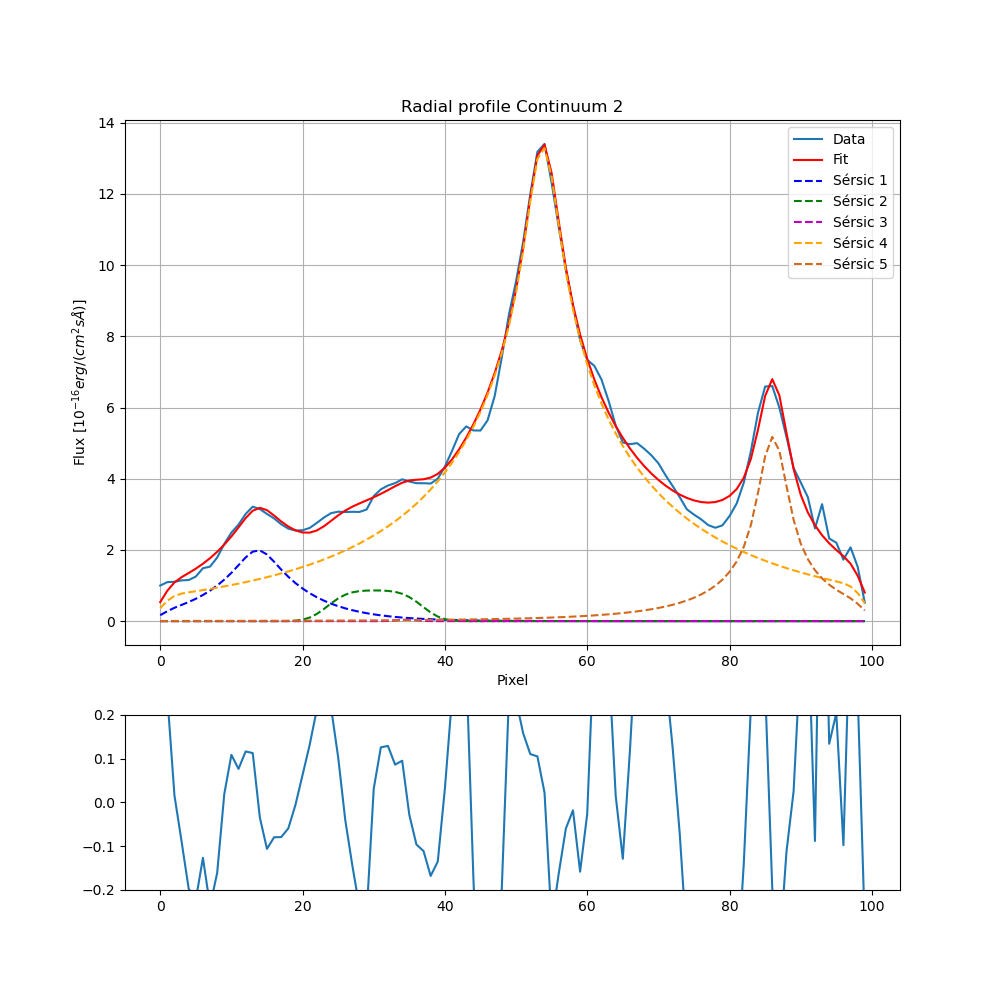

In [88]:
save_params_diff(best_params, radial_profile_continuum_2, real_errors_c2, sigmas[-1],
    x_axes, n_component, line_name="Continuum_2", output_prefix="fit")
plot_diff(x_axes, best_params, radial_profile_continuum_2, sigmas[-1], r"Radial profile Continuum 2")
plt.savefig('Radial_profile_continuum_2_diff')

In [89]:
lower_bounds, upper_bounds = zip(*bounds)
bounds_list = (list(lower_bounds), list(upper_bounds))
params_curve_continuum_2, covariance_continuum_2 = curve_fit(lambda x, *params: model_convolved(x, sigmas[-1], *params), x_axes, radial_profile_continuum_2, p0=result.x, 
                                                             sigma = real_errors_c2, bounds = bounds_list, maxfev=15000)
print("Optimize parameters with curve fit:")
chi2_reduced_continuum_2, dof_continuum_2, chi2_continuum_2 = save_params(params_curve_continuum_2, covariance_continuum_2, radial_profile_continuum_2,
                                                                          real_errors_c2, sigmas[-1], x_axes, n_component, line_name="Continuum_2", output_prefix="fit")

Optimize parameters with curve fit:
Sérsic 1: I_e=0.3126, r_e=13.7707, n=1.2221, x_0=13.8238
Sérsic 2: I_e=0.6659, r_e=5.0000, n=0.2383, x_0=30.1479
Sérsic 3: I_e=0.1194, r_e=0.1906, n=1.9187, x_0=34.5813
Sérsic 4: I_e=0.8139, r_e=50.0000, n=1.7063, x_0=53.9165
Sérsic 5: I_e=0.5226, r_e=10.7301, n=1.5664, x_0=86.4637
[2.77601586e-01 1.66744120e+01 6.33861114e-01 4.20101421e-01
 3.26102485e-01 1.33454978e+00 3.56507263e-01 2.18307045e+00
 2.06656743e+03 5.40068264e+02 2.57177850e+04 1.17629060e+01
 5.58158341e-01 3.49901314e+01 4.25099179e-01 2.06923399e-01
 5.98414408e-01 1.24726753e+01 7.96451834e-01 1.92052946e-01]
4.903880972576799


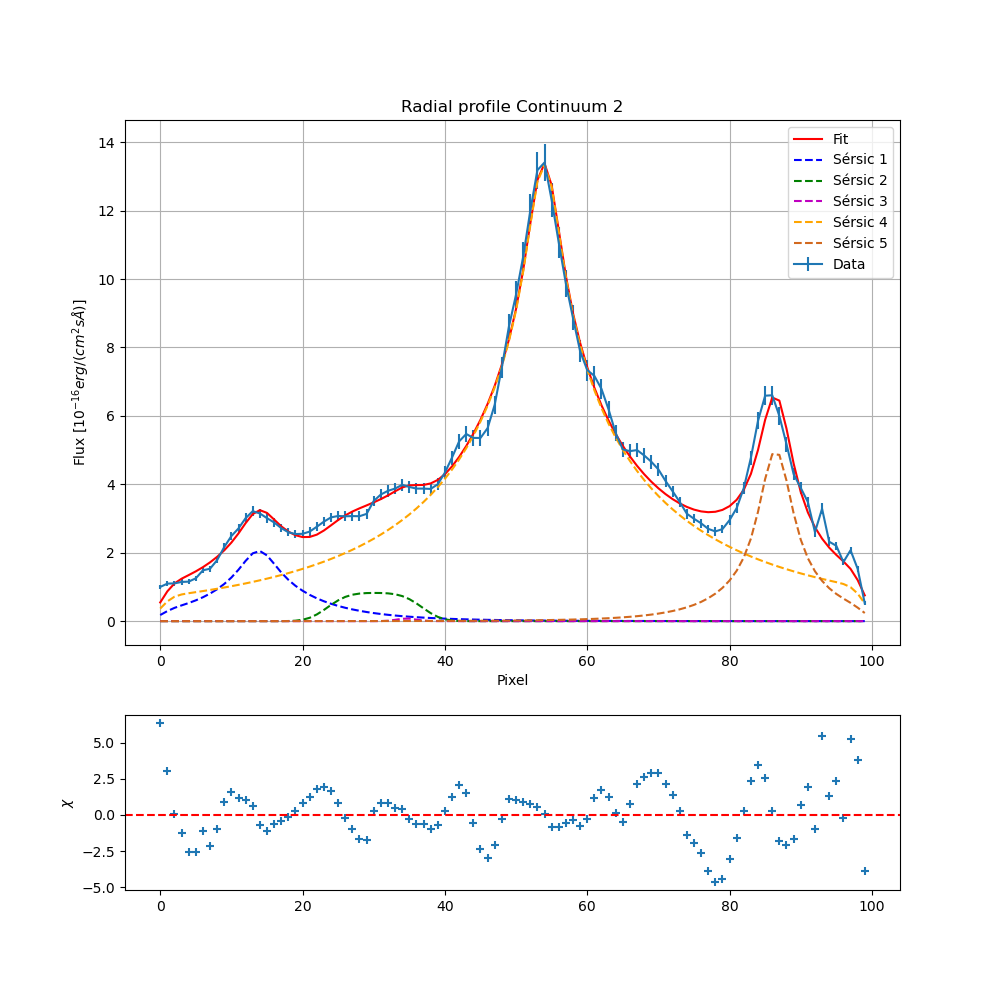

In [90]:
plot_curve(x_axes, params_curve_continuum_2, radial_profile_continuum_2, real_errors_c2, sigmas[-1], r"Radial profile Continuum 2")
plt.savefig('Radial_profile_continuum_2_curve')

##  Continuum 3

Text(0.5, 1.0, 'Continuum 3')

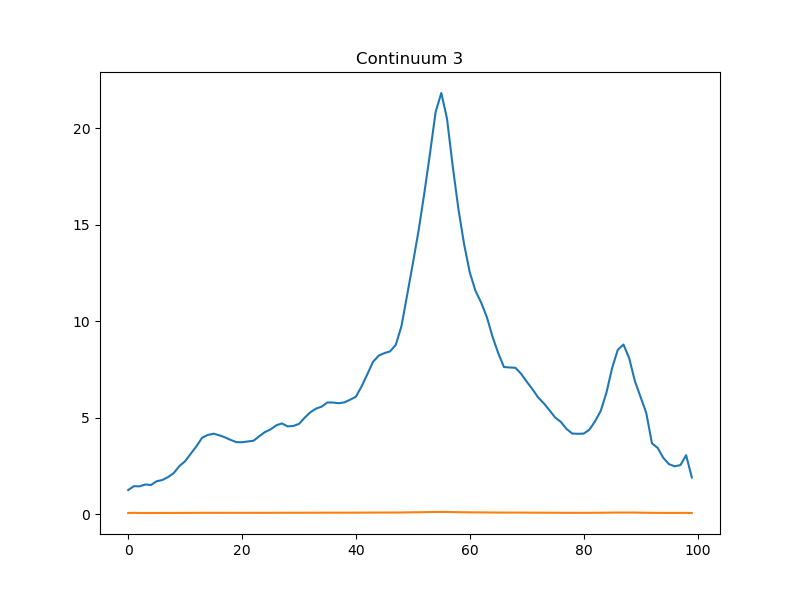

In [91]:
mask_continuum_3 = (wv > 5810)*(wv < 6210)
image_continuum_3 = image_cut[:, mask_continuum_3]
image_error_continuum_3 = image_error_cut[:, mask_continuum_3]
radial_profile_continuum_3 = np.sum(image_continuum_3, axis = 1)
radial_profile_error_continuum_3 = np.sqrt(np.sum(image_error_continuum_3**2, axis = 1))
real_errors_c3 = np.sqrt(radial_profile_error_continuum_3**2+(sky_err[2])**2+(0.04*radial_profile_continuum_3)**2)

x_axes = np.arange(0, 100, 1)
plt.figure(figsize=(8,6))
plt.plot(x_axes, radial_profile_continuum_3)
plt.plot(x_axes, radial_profile_error_continuum_3)
plt.title(r'Continuum 3')

In [92]:
# Bounds:
bounds = bounds_HA

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_continuum_3, sigmas[0])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 771.3878021661866
differential_evolution step 2: f(x)= 473.106783393154
differential_evolution step 3: f(x)= 473.106783393154
differential_evolution step 4: f(x)= 230.01373515255247
differential_evolution step 5: f(x)= 230.01373515255247
differential_evolution step 6: f(x)= 230.01373515255247
differential_evolution step 7: f(x)= 222.56562641773246
differential_evolution step 8: f(x)= 130.39482072034968
differential_evolution step 9: f(x)= 130.39482072034968
differential_evolution step 10: f(x)= 130.39482072034968
differential_evolution step 11: f(x)= 130.39482072034968
differential_evolution step 12: f(x)= 130.39482072034968
differential_evolution step 13: f(x)= 130.39482072034968
differential_evolution step 14: f(x)= 130.39482072034968
differential_evolution step 15: f(x)= 125.0386517324001
differential_evolution step 16: f(x)= 68.71950059832884
differential_evolution step 17: f(x)= 68.71950059832884
differential_evolution step 18: f(x)= 68.7195005

Sérsic 1: I_e=0.1729, r_e=49.9999, n=1.6556, x_0=15.7197
Sérsic 2: I_e=0.7858, r_e=4.9995, n=0.1565, x_0=30.1480
Sérsic 3: I_e=0.4281, r_e=4.9999, n=0.1437, x_0=37.7563
Sérsic 4: I_e=1.0000, r_e=49.9999, n=1.9080, x_0=54.9252
Sérsic 5: I_e=0.1385, r_e=49.9993, n=2.5656, x_0=86.9932


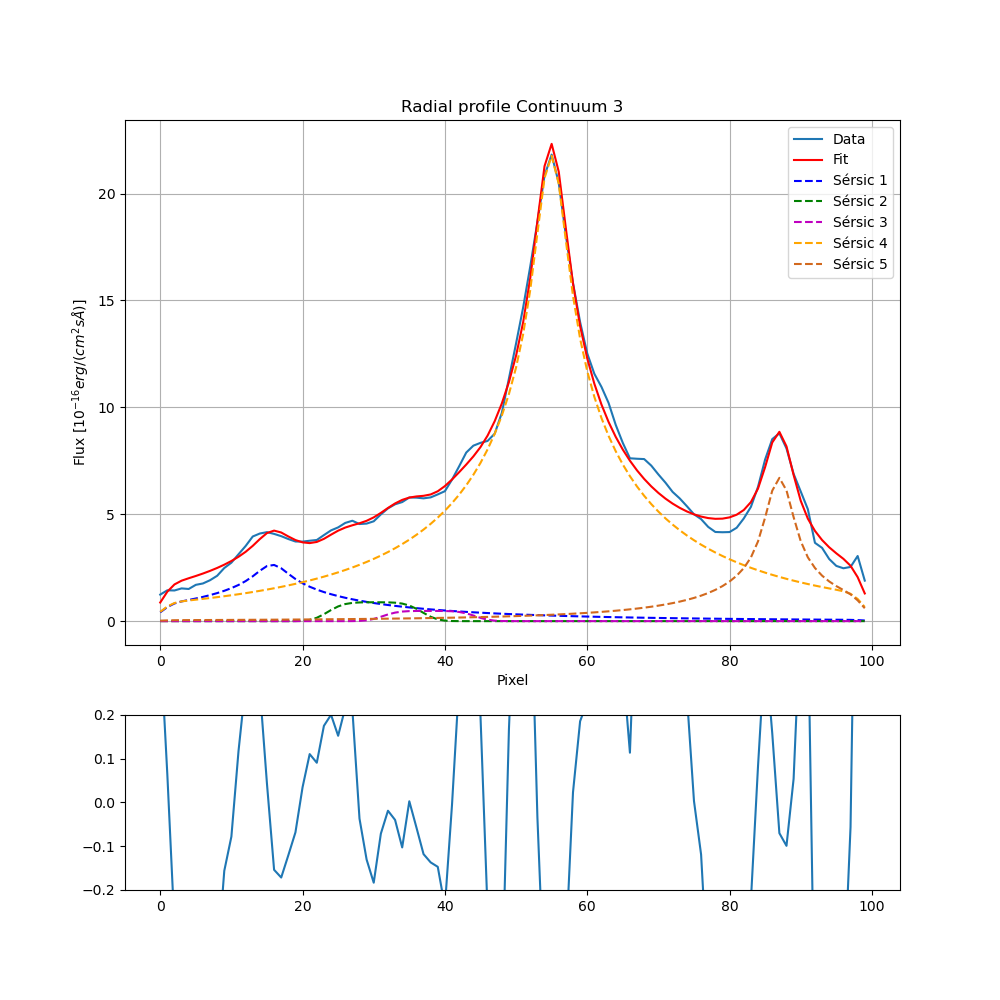

In [93]:
save_params_diff(best_params, radial_profile_continuum_3, real_errors_c3, sigmas[0],
    x_axes, n_component, line_name="Continuum_3", output_prefix="fit")
plot_diff(x_axes, best_params, radial_profile_continuum_3, sigmas[0], r"Radial profile Continuum 3")
plt.savefig('Radial_profile_continuum_3_diff')

In [95]:
lower_bounds, upper_bounds = zip(*bounds)
bounds_list = (list(lower_bounds), list(upper_bounds))
params_curve_continuum_3, covariance_continuum_3 = curve_fit(lambda x, *params: model_convolved(x, sigmas[0], *params), x_axes,
                                                             radial_profile_continuum_3, p0=result.x, sigma = real_errors_c3, bounds = bounds_list, maxfev = 10000)
print("Optimize parameters with curve fit:")
chi2_reduced_continuum_3, dof_continuum_3, chi2_continuum_3 = save_params(params_curve_continuum_3, covariance_continuum_3, radial_profile_continuum_3,
                                                                          real_errors_c3, sigmas[0], x_axes, n_component, line_name="Continuum_3", output_prefix="fit")

Optimize parameters with curve fit:
Sérsic 1: I_e=0.1198, r_e=48.7129, n=1.9837, x_0=15.4266
Sérsic 2: I_e=0.9999, r_e=5.0000, n=0.2219, x_0=30.1479
Sérsic 3: I_e=0.4348, r_e=4.7092, n=0.1427, x_0=37.7563
Sérsic 4: I_e=1.0000, r_e=49.9999, n=1.9406, x_0=55.0675
Sérsic 5: I_e=0.1154, r_e=49.8617, n=2.7621, x_0=87.0428
[2.06492816e-01 9.66285204e+01 1.11393633e+00 4.19630691e-01
 3.09716611e-01 1.58878967e+00 3.23933486e-01 2.24946075e+00
 6.71913139e-01 1.19034509e+01 1.35628987e+00 3.29888286e+00
 7.36133632e-01 3.82161548e+01 4.74942657e-01 1.80428113e-01
 6.27383191e-01 2.24556378e+02 4.32523535e+00 7.48247488e-03]
4.808075897822993


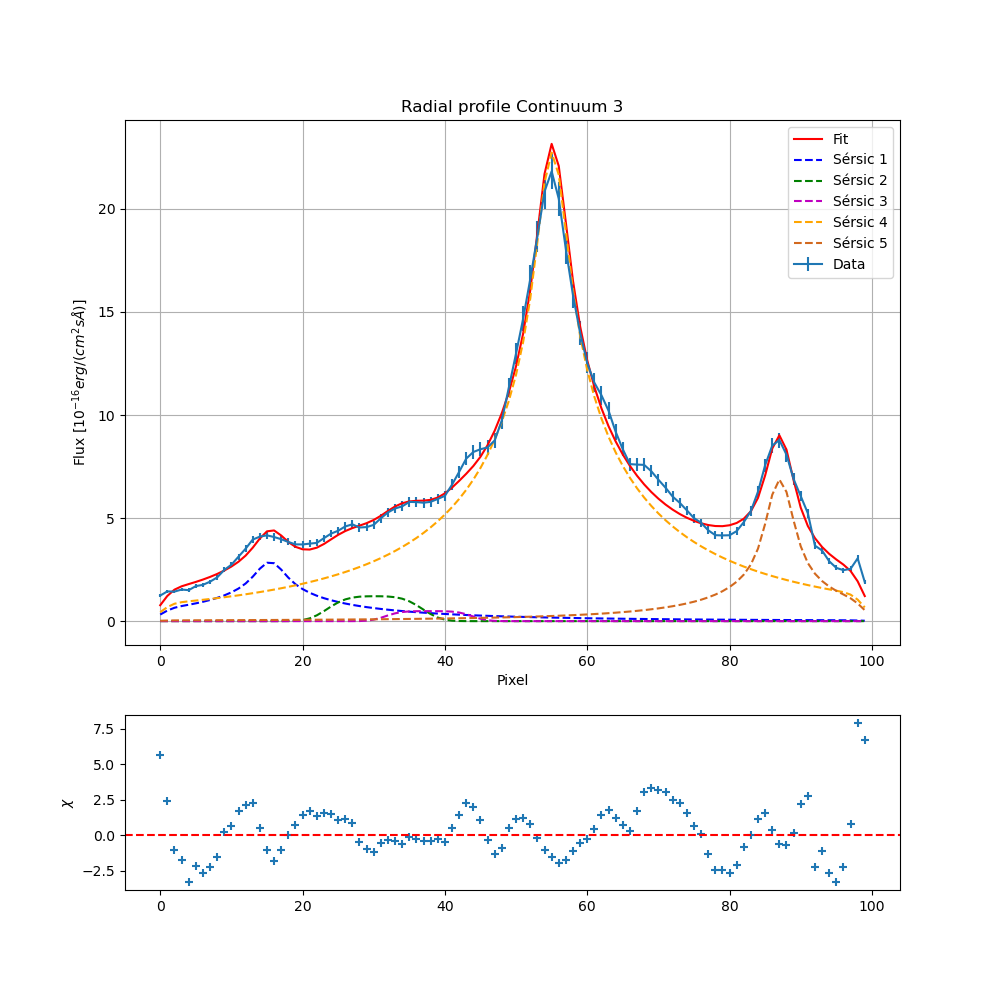

In [96]:
plot_curve(x_axes, params_curve_continuum_3, radial_profile_continuum_3, real_errors_c3, sigmas[0], r"Radial profile Continuum 3")
plt.savefig('Radial_profile_continuum_3_curve')

## Chi squared save

In [97]:
chi_red = [chi2_reduced_continuum_1, chi2_reduced_continuum_2, chi2_reduced_continuum_3]
dof = [dof_continuum_1, dof_continuum_2, dof_continuum_3]
chi = [chi2_continuum_1, chi2_continuum_2, chi2_continuum_3]

d1 = {'Name': ['Continuum 1', 'Continuum 2', 'Continuum 3'], 'Chi squared': chi,
      'Dof': dof, 'Chi reduced': chi_red}
df1 = pd.DataFrame(data=d1)
df1.to_csv("Chi_squared_curve_fit_continuum.csv", index= False)

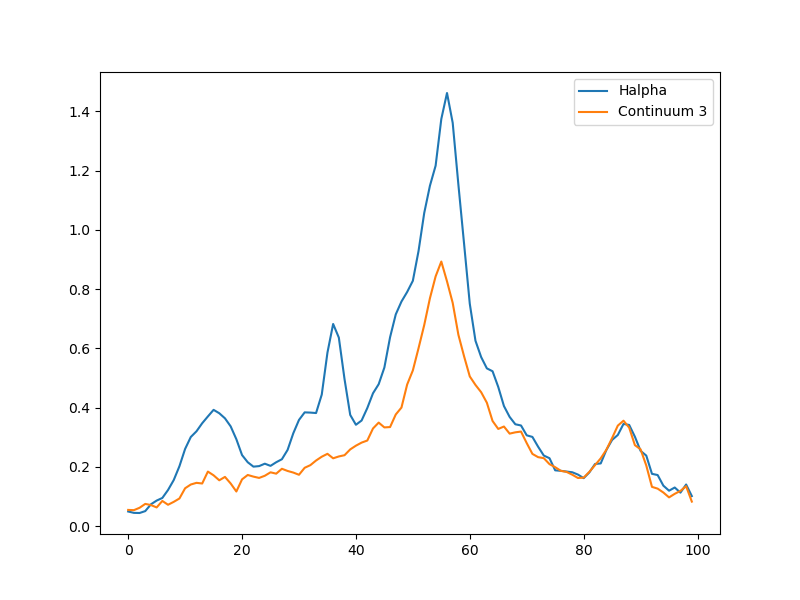

In [98]:
mask_continuum_3 = (wv > 5984)*(wv < 6000)
image_continuum_3 = image_cut[:, mask_continuum_3]
image_error_continuum_3 = image_error_cut[:, mask_continuum_3]
radial_profile_continuum_3 = np.sum(image_continuum_3, axis = 1)
radial_profile_error_continuum_3 = np.sqrt(np.sum(image_error_continuum_3**2, axis = 1))
plt.figure(figsize=(8,6))
plt.plot(x_axes, radial_profile_HA, label = 'Halpha')
plt.plot(x_axes, radial_profile_continuum_3, label = 'Continuum 3')
plt.legend()
plt.savefig('Halpha_vs_continuum')

# 